# Neutrino fluxes along the muon accelerator chain

Forward neutrino fluxes from muon decays in each machine of the accelerator chain --
the pre-accelerator (PA), the two recirculating linacs (RLA1, RLA2), and the 10 TeV
collider ring -- compared on a single plot for a detector 1 km from the origin of each
machine.

Each machine is simulated separately (no merged PA+RLA lattice): **vegas runs only
once** to generate the master rest-frame decay sample, and every (machine, flavor) case
is an exact `reweighted_copy` placed on that machine's lattice. The rest-frame sample is
machine-independent -- the boost to the lab frame happens at placement, using each
lattice's momentum profile `beam_p0(s)`.

Machine parameters follow `main_RLA_studies.ipynb`; the collider ring is the packaged
`mc_10tev_hybrid_v06` lattice used in `main_collider_ring_studies.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import mint
from mint import const
from mint import lattice_tools as lt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

os.makedirs("plots", exist_ok=True)

## 1. Build the machines

- **PA**: 160 m straight accelerating section, $p_\mu$: 0.225 → 1.25 GeV.
- **RLA1**: recirculating linac (half droplet), 70 m straights, $p_\mu$: 1.25 → 5 GeV.
- **RLA2**: recirculating linac, 829 m straights, $p_\mu$: 5 → 63 GeV.
- **MuC ring**: 10 TeV collider ring ($p_\mu = 5$ TeV), loaded by name from `mint.lattices`.

[2.15768000e+03 2.15780349e+03 2.15792699e+03 ... 1.00000000e-03
 1.00000000e-03 1.00000000e-03]
[ 2157.68        2160.60501144  2163.53002288 ... 17587.56156373
 17590.48657517 17593.4115866 ]
PA: length 160 m, p_mu 0.225 -> 1.25 GeV
RLA1: length 1200 m, p_mu 1.25 -> 5 GeV
RLA2: length 14631 m, p_mu 5 -> 63 GeV
MuC ring: length 1465 m, p_mu 5000 -> 5000 GeV


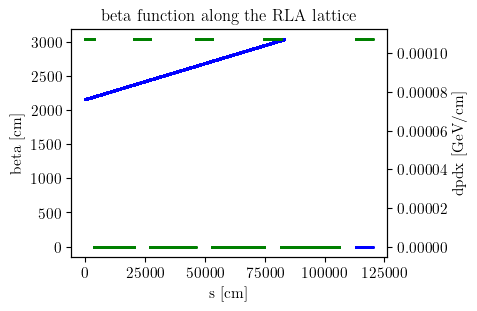

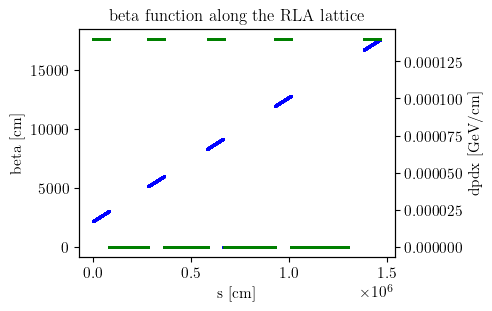

In [5]:
pa_lattice = lt.create_straight_lattice(
    name="PA",
    short_name="pa",
    total_length=160e2,
    n_elements=100_000,
    p0_injected=0.225,
    p0_ejected=1.25,
    beamdiv=1e-3,
    beamdiv_z=1e-2,
    beamsize=1.0,
    Nmu_per_bunch=2e12,
)

rla1_lattice = lt.create_RLA_lattice(
    name="RLA1",
    short_name="rla1",
    straight_length=70e2,
    n_elements=100_000,
    p0_injection=1.25,
    dp_dx_LA=0.75 / 70e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=True,
    Nmu_per_bunch=2e12,
)

rla2_lattice = lt.create_RLA_lattice(
    name="RLA2",
    short_name="rla2",
    straight_length=829e2,
    n_elements=100_000,
    p0_injection=5.0,
    dp_dx_LA=11.6 / 829e2,
    beamdiv_z=1e-2,
    beamdiv=1e-3,
    beamsize=1e-2,
    half=False,
    Nmu_per_bunch=2e12,
)

ring = mint.lattices.load("mc_10tev_hybrid_v06")

machines = {
    "PA": {"lattice": pa_lattice, "p_range": (0.225, 1.25)},
    "RLA1": {"lattice": rla1_lattice, "p_range": (1.25, 5.0)},
    "RLA2": {"lattice": rla2_lattice, "p_range": (5.0, 63.0)},
    "MuC ring": {"lattice": ring, "p_range": (5e3, 5e3)},
}

for name, cfg in machines.items():
    lat = cfg["lattice"]
    print(f"{name}: length {lat.s(1) * 1e-2:.0f} m, "
          f"p_mu {cfg['p_range'][0]:g} -> {cfg['p_range'][1]:g} GeV")

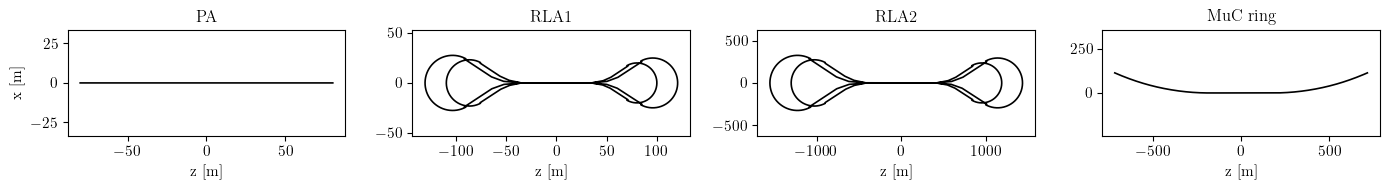

In [6]:
# Geometry overview (world x-z plane; the detector sits on the +z axis)
u = np.linspace(0, 1, 3000)
fig, axes = plt.subplots(1, 4, figsize=(14, 2))
for ax, (name, cfg) in zip(axes, machines.items()):
    lat = cfg["lattice"]
    ax.plot(lat.z(u) * 1e-2, lat.x(u) * 1e-2, lw=1.2, color="black")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("z [m]")
    ax.set_aspect("equal", adjustable="datalim")
axes[0].set_ylabel("x [m]")
fig.tight_layout()

## 2. Simulate the decays

One vegas run generates the master sample ($\bar\nu_\mu$, $P = 0$); each (machine,
flavor) case is a reweighted copy placed on that machine. Exposure per bunch:

- PA / RLA1 / RLA2: a single pass through the machine (`cycles = 1`);
- MuC ring: one full injection period (`cycles = "full_injection"`, machine turns
  computed from `ring.total_circumference`).

All machines are normalized to the same injection cycle: every injected bunch traverses
each accelerator stage once and is then stored in the collider ring, so a common
"bunches per year" (from the ring's $f_{\rm inj}$ and duty factor) applies to all.

In [7]:
N_EVALS = 5e6   # MC statistics; lower (e.g. 2e5) for quick runs

In [8]:
sim_base = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor="numubar",
    lattice=ring,
    cycles="full_injection",
    n_evals=N_EVALS,
    beam_dynamics=True,
)
ring_cycles = sim_base.cycles
print(f"machine turns per injection period (ring): {ring_cycles:.0f}")
sim_base.decay_muons()
print(f"vegas sample generated: {sim_base.sample_size} events")

sims = {name: {} for name in machines}
for name, cfg in machines.items():
    cycles = ring_cycles if name == "MuC ring" else 1
    for flavor in ["numubar", "nue"]:
        sim = sim_base.reweighted_copy(nuflavor=flavor)
        sim.cycles = cycles
        sim.place_muons_on_lattice(lattice=cfg["lattice"], direction="clockwise")
        sims[name][flavor] = sim
    print(f"placed {name} (cycles = {cycles:g})")

machine turns per injection period (ring): 5996
vegas sample generated: 4691696 events
placed PA (cycles = 1)
placed RLA1 (cycles = 1)
placed RLA2 (cycles = 1)


/Users/jchoi55/Documents/GitHub/MINeut/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


placed MuC ring (cycles = 5995.85)


## 3. Flux at a detector 1 km from the origin

Flux per cm$^2$ per GeV per year through a 2 m-radius detector face on the $+z$ axis,
1 km from the origin of each machine.

In [9]:
det_location = np.array([0.0, 0.0, 1e5])   # 1 km downstream, on axis
det_radius = 2e2                            # cm

bunches_per_year = ring.finj * ring.bunch_multiplicity * ring.duty_factor * const.s_in_year
print(f"Bunch crossings per year: {bunches_per_year:.2e}")

# Log-spaced bins spanning the PA (sub-GeV) through the collider ring (multi-TeV)
energy_edges = np.geomspace(1e-1, 6e3, 100)

fluxes = {}
for name in machines:
    fluxes[name] = {}
    for flavor in ["numubar", "nue"]:
        e_edges, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_location,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        fluxes[name][flavor] = flux
        total = np.sum(flux * np.diff(energy_edges))
        print(f"{name} {flavor}: integrated flux {total:.3e} / cm^2 / year")

Bunch crossings per year: 5.02e+07
PA numubar: integrated flux 5.902e+09 / cm^2 / year
PA nue: integrated flux 5.412e+09 / cm^2 / year
RLA1 numubar: integrated flux 2.412e+10 / cm^2 / year
RLA1 nue: integrated flux 2.344e+10 / cm^2 / year
RLA2 numubar: integrated flux 1.774e+12 / cm^2 / year
RLA2 nue: integrated flux 1.776e+12 / cm^2 / year
MuC ring numubar: integrated flux 2.421e+13 / cm^2 / year
MuC ring nue: integrated flux 2.423e+13 / cm^2 / year


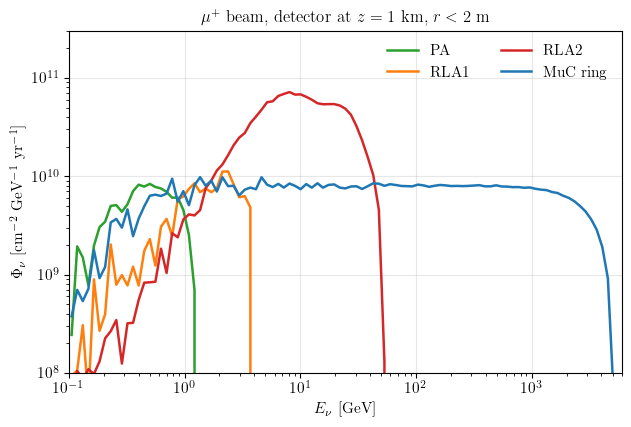

In [10]:
energy_centers = np.sqrt(energy_edges[1:] * energy_edges[:-1])

machine_colors = {
    "PA": "tab:green",
    "RLA1": "tab:orange",
    "RLA2": "tab:red",
    "MuC ring": "tab:blue",
}
flavor_style = {"numubar": ("-", r"$\bar\nu_\mu$")}#, "nue": ("--", r"$\nu_e$")}

fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    for flavor, (ls, _) in flavor_style.items():
        ax.plot(energy_centers, fluxes[name][flavor], ls=ls, lw=1.8,
                color=machine_colors[name])

# Legend: one color entry per machine, one linestyle entry per flavor
from matplotlib.lines import Line2D
machine_handles = [Line2D([], [], color=c, lw=1.8, label=n)
                   for n, c in machine_colors.items()]
# flavor_handles = [Line2D([], [], color="black", lw=1.8, ls=ls, label=lab)
#                   for ls, lab in flavor_style.values()]
ax.legend(handles=machine_handles, frameon=False,
          fontsize=11, ncol=2, loc="upper right")

ax.set_xscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e8, 3e11)
ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_\nu$ [cm$^{-2}$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(rf"$\mu^+$ beam, detector at $z = 1$ km, $r < {det_radius * 1e-2:.0f}$ m")
ax.grid(True, which="major", ls="-", alpha=0.3)
fig.savefig("plots/machine_flux_comparison_1km.pdf", dpi=300, bbox_inches="tight")

## 4. Event rates in a $\rho \ell = 1$ kg/cm$^2$ detector

Interactions per year in a detector with nucleon column density $\rho\ell = 1$ kg/cm$^2$
and radius 2 m. To keep the geometry comparable across machines of very different size,
each detector sits at $z_{\rm det} = 2 \times z_{\rm max}$, twice the downstream
$z$-extent of its machine (160 m for the PA, up to a few km for RLA2 and the ring).

**Cross-section caveat:** the DIS tables in `mint.xsecs` start at 50 GeV (and return 0
below); below that edge we extrapolate linearly in $E_\nu$ (the DIS scaling
$\sigma \propto E$). At PA energies ($\lesssim 1$ GeV) the true cross section is
QE/resonance dominated, so those rates are rough estimates.

In [11]:
from mint import xsecs

# Detector: rho * L = 1 kg/cm^2, r = 2 m, at z_det = 2 x (z-extent of each lattice)
rho_L_g_cm2 = 1e3                      # rho * L = 1 kg/cm^2
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 2e2                       # cm
det_area_cm2 = np.pi * det_radius**2


def sigma_total_lowE(flavor):
    """total_xsecs with a linear-in-E extrapolation below the 50 GeV edge of the
    DIS table (which returns 0 there). sigma ~ E is the DIS scaling; at sub-GeV
    energies (PA) the true QE/RES cross section differs -- rough estimate only."""
    base = xsecs.total_xsecs[flavor]
    E0 = 50.0
    s0 = float(base(E0))
    return lambda E: np.where(np.asarray(E) >= E0, base(E), s0 * np.asarray(E) / E0)


e_centers = np.sqrt(energy_edges[1:] * energy_edges[:-1])
u_fine = np.linspace(0, 1, 5000)

event_rates, det_z_m = {}, {}
for name, cfg in machines.items():
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    det_loc = np.array([0.0, 0.0, 2.0 * z_extent])
    det_z_m[name] = det_loc[2] * 1e-2
    event_rates[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m): "
              f"{flavor} {total:.4g} events / year")


PA (detector at z = 160 m): numubar 7.69e+04 events / year
PA (detector at z = 160 m): nue 1.339e+05 events / year
RLA1 (detector at z = 242 m): numubar 2.819e+05 events / year
RLA1 (detector at z = 242 m): nue 4.843e+05 events / year
RLA2 (detector at z = 2861 m): numubar 1.703e+06 events / year
RLA2 (detector at z = 2861 m): nue 3.014e+06 events / year
MuC ring (detector at z = 1433 m): numubar 1.531e+10 events / year
MuC ring (detector at z = 1433 m): nue 2.197e+10 events / year


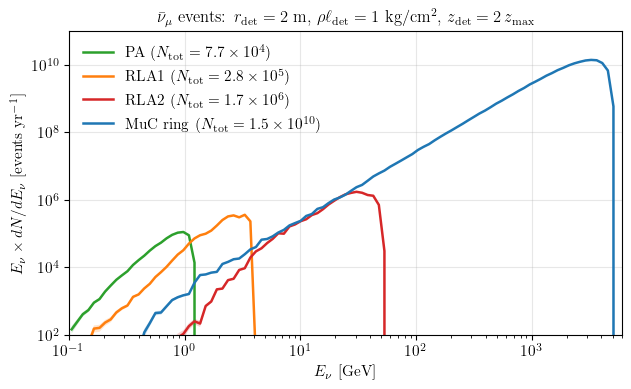

In [12]:
from mint import plot_tools as pt
fig, ax = pt.std_fig(figsize=(7, 4))
for name in machines:
    y = event_rates[name]["numubar"]
    dE = np.diff(energy_edges)

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers*y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers*(y - yerr), 1e-30, None),
        e_centers*(y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, loc='upper left', ncol=1)
fig.savefig("plots/machine_event_rate_2zmax.pdf", dpi=300, bbox_inches="tight")

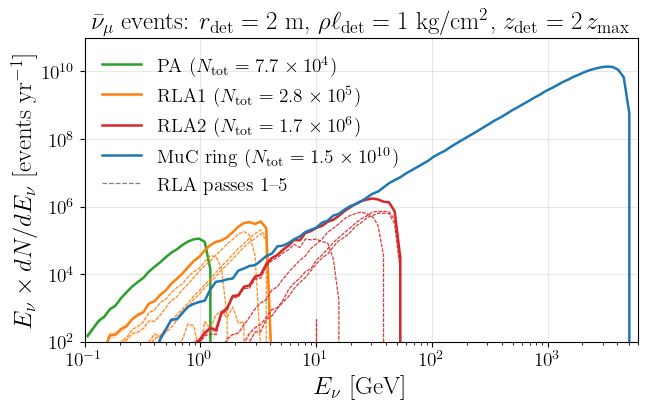

In [13]:
# Same event-rate plot, with the RLA curves split into their linac passes.
# which_pass(u) = 1..5 tags each decay with its traversal of the machine; the beam
# momentum grows pass by pass, so later passes contribute harder neutrinos.
# Passes are masked with get_flux_at_generic_location(mask=...) and sum exactly
# to the solid total.
from matplotlib.lines import Line2D

fig, ax = pt.std_fig(figsize=(7, 4))
dE = np.diff(energy_edges)
sigma_numubar = sigma_total_lowE("numubar")(e_centers)

for name, cfg in machines.items():
    y = event_rates[name]["numubar"]

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers * y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers * (y - yerr), 1e-30, None),
        e_centers * (y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )

    if name not in ("RLA1", "RLA2"):
        continue

    # Per-pass contributions (thin dashed, same color as the machine)
    lat = cfg["lattice"]
    sim = sims[name]["numubar"]
    z_extent = float(np.max(lat.z(np.linspace(0, 1, 5000))))
    det_loc = np.array([0.0, 0.0, 2.0 * z_extent])
    pass_id = np.rint(np.asarray(lat.which_pass(lat.inv_s(sim.s_in_turn)))).astype(int)

    for k in np.unique(pass_id):
        _, flux_k = sim.get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
            mask=(pass_id == k),
        )
        if np.isscalar(flux_k):
            continue
        y_k = flux_k * det_area_cm2 * sigma_numubar * nucleon_column_density
        n_bin_k = y_k * dE
        yerr_k = np.sqrt(np.clip(n_bin_k, 0.0, None)) / dE

        ax.plot(
            e_centers, e_centers * y_k,
            ls=(1, (3, 1)), lw=0.9, alpha=0.9, color=machine_colors[name]
        )
        ax.fill_between(
            e_centers,
            np.clip(e_centers * (y_k - yerr_k), 1e-30, None),
            e_centers * (y_k + yerr_k),
            color=machine_colors[name],
            alpha=0.08,
            linewidth=0,
        )

handles, _ = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="gray", ls="--", lw=0.9, label="RLA passes 1--5"))

ax.set_yticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10])
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=18)
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]", fontsize=18)
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$", fontsize=18)
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(handles=handles, frameon=False, fontsize=14, loc="upper left", ncol=1)
fig.savefig("plots/machine_event_rate_2zmax_passes.pdf", dpi=300, bbox_inches="tight")

## 5. Same studies without beam dynamics

Placement with `beam_dynamics = False`: muons sit exactly on the reference orbit with
zero transverse size, divergence, and momentum spread, so the neutrino angular spread is
purely from the decay kinematics ($\theta \sim 1/\gamma_\mu$).

To keep the memory footprint flat with the $10^7$-event sample, each no-BD copy is
discarded (`del sim`) as soon as its fluxes are computed.

In [14]:
fluxes_nobd, event_rates_nobd, det_z_m = {}, {}, {}
u_fine = np.linspace(0, 1, 5000)

for name, cfg in machines.items():
    fluxes_nobd[name], event_rates_nobd[name] = {}, {}
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    det_z_m[name] = 2.0 * z_extent * 1e-2
    cycles = ring_cycles if name == "MuC ring" else 1
    for flavor in ["numubar", "nue"]:
        sim = sim_base.reweighted_copy(nuflavor=flavor)
        sim.cycles = cycles
        sim.beam_dynamics = False
        sim.place_muons_on_lattice(lattice=cfg["lattice"], direction="clockwise")

        # flux through the 1 km, r < 2 m detector face (as in section 3)
        _, flux_1km = sim.get_flux_at_generic_location(
            det_location=np.array([0.0, 0.0, 1e5]),
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        fluxes_nobd[name][flavor] = flux_1km

        # event rate in the rho*L = 1 kg/cm^2 detector at z = 2 z_max (as in section 4)
        _, flux_det = sim.get_flux_at_generic_location(
            det_location=np.array([0.0, 0.0, 2.0 * z_extent]),
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        event_rates_nobd[name][flavor] = (
            flux_det * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
            * nucleon_column_density
        )
        del sim   # free the placement before the next copy
    print(f"{name}: no-BD fluxes and event rates computed")

PA: no-BD fluxes and event rates computed
RLA1: no-BD fluxes and event rates computed
RLA2: no-BD fluxes and event rates computed
MuC ring: no-BD fluxes and event rates computed


PA numubar (no BD): integrated flux 5.777e+09 / cm^2 / year
RLA1 numubar (no BD): integrated flux 2.393e+10 / cm^2 / year
RLA2 numubar (no BD): integrated flux 2.444e+12 / cm^2 / year
MuC ring numubar (no BD): integrated flux 2.446e+13 / cm^2 / year


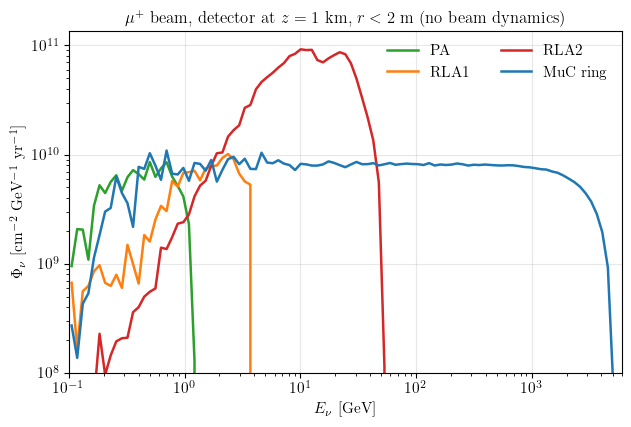

In [15]:
# Flux at 1 km, no beam dynamics (same style as section 3)
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, fluxes_nobd[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
    total = np.sum(fluxes_nobd[name]["numubar"] * np.diff(energy_edges))
    print(f"{name} numubar (no BD): integrated flux {total:.3e} / cm^2 / year")

ax.legend(frameon=False, fontsize=11, ncol=2, loc="upper right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e8, None)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_\nu$ [cm$^{-2}$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(rf"$\mu^+$ beam, detector at $z = 1$ km, $r < {det_radius * 1e-2:.0f}$ m (no beam dynamics)")
ax.grid(True, which="major", ls="-", alpha=0.3)
fig.savefig("plots/machine_flux_comparison_1km_noBD.pdf", dpi=300, bbox_inches="tight")

PA (detector at z = 160 m, no BD): numubar 7.749e+04 events / year
PA (detector at z = 160 m, no BD): nue 1.337e+05 events / year
RLA1 (detector at z = 242 m, no BD): numubar 2.826e+05 events / year
RLA1 (detector at z = 242 m, no BD): nue 4.972e+05 events / year
RLA2 (detector at z = 2861 m, no BD): numubar 3.781e+06 events / year
RLA2 (detector at z = 2861 m, no BD): nue 6.518e+06 events / year
MuC ring (detector at z = 1433 m, no BD): numubar 1.582e+10 events / year
MuC ring (detector at z = 1433 m, no BD): nue 2.265e+10 events / year


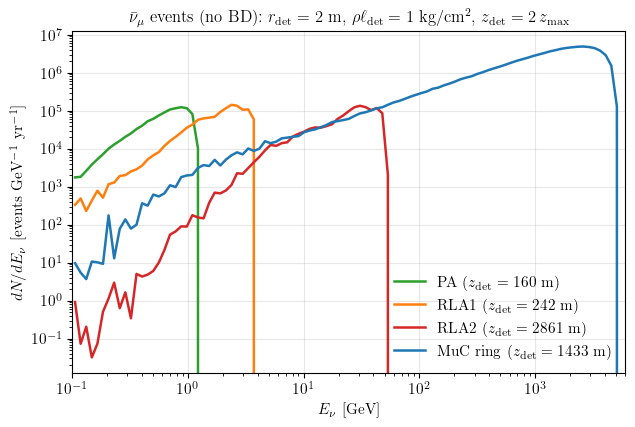

In [16]:
# Event rates at z = 2 z_max, no beam dynamics (same style as section 4)
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, event_rates_nobd[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name],
            label=rf"{name} ($z_{{\rm det}} = {det_z_m[name]:.0f}$ m)")
    for flavor in ["numubar", "nue"]:
        total = np.sum(event_rates_nobd[name][flavor] * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m, no BD): "
              f"{flavor} {total:.4g} events / year")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN/dE_\nu$ [events GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events (no BD): $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = 2\, z_{\rm max}$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11)
fig.savefig("plots/machine_event_rate_2zmax_noBD.pdf", dpi=300, bbox_inches="tight")

## 6. Full-acceptance detector: spherical shell with $\rho \ell = 1$ kg/cm $^2$

A closed shell around the machine catches **every** neutrino, so the geometry drops out
entirely: the event rate is the total neutrino production spectrum times the interaction
probability,
$dN/dE = (d\Phi_\nu/dE)\, \sigma(E)\, \rho\ell / m_p$.
No detector placement is involved, and beam dynamics are irrelevant at this level (the
BD-on simulations are used). This is the ceiling on what any detector arrangement could
collect per machine.

PA numubar: 2.870e+18 neutrinos / year -> 2.234e+06 events / year
PA nue: 2.623e+18 neutrinos / year -> 3.778e+06 events / year
RLA1 numubar: 6.634e+18 neutrinos / year -> 1.754e+07 events / year
RLA1 nue: 6.531e+18 neutrinos / year -> 3.052e+07 events / year
RLA2 numubar: 8.049e+18 neutrinos / year -> 2.144e+08 events / year
RLA2 nue: 8.039e+18 neutrinos / year -> 3.737e+08 events / year
MuC ring numubar: 1.256e+19 neutrinos / year -> 6.651e+10 events / year
MuC ring nue: 1.257e+19 neutrinos / year -> 9.55e+10 events / year


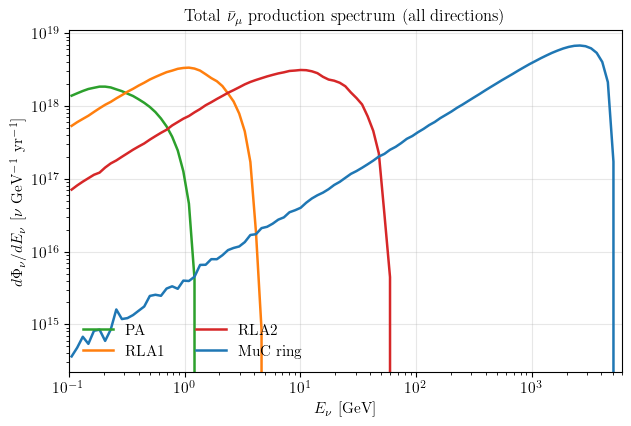

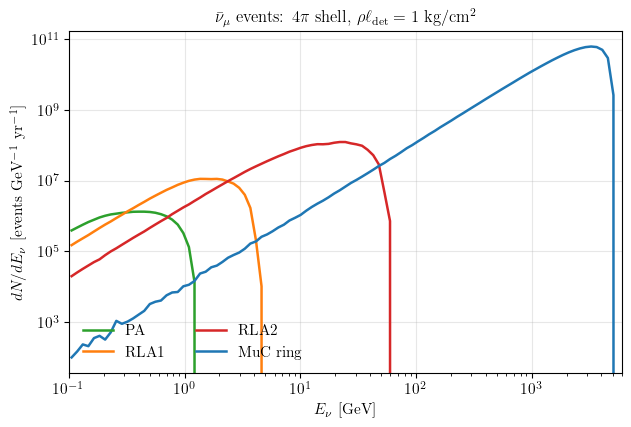

In [17]:
nu_spectra_4pi, event_rates_4pi = {}, {}
for name in machines:
    nu_spectra_4pi[name], event_rates_4pi[name] = {}, {}
    for flavor in ["numubar", "nue"]:
        sim = sims[name][flavor]
        counts, _ = np.histogram(sim.pnu["E"], bins=energy_edges,
                                 weights=sim.weights.flatten() * bunches_per_year)
        dPhi_dE = counts / np.diff(energy_edges)       # neutrinos / GeV / year
        nu_spectra_4pi[name][flavor] = dPhi_dE
        event_rates_4pi[name][flavor] = (
            dPhi_dE * sigma_total_lowE(flavor)(e_centers) * nucleon_column_density
        )
        total_nu = np.sum(counts)
        total_ev = np.sum(event_rates_4pi[name][flavor] * np.diff(energy_edges))
        print(f"{name} {flavor}: {total_nu:.3e} neutrinos / year "
              f"-> {total_ev:.4g} events / year")

# Total neutrino production spectrum
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, e_centers*nu_spectra_4pi[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"Total $\bar\nu_\mu$ production spectrum (all directions)")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, ncol=2, loc="lower left")
fig.savefig("plots/machine_nu_spectrum_4pi.pdf", dpi=300, bbox_inches="tight")

# Event-rate spectrum in the shell
fig, ax = pt.std_fig(figsize=(7, 4.5))
for name in machines:
    ax.plot(e_centers, e_centers*event_rates_4pi[name]["numubar"], "-", lw=1.8,
            color=machine_colors[name], label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$dN/dE_\nu$ [events GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $4\pi$ shell, $\rho \ell_{\rm det} = 1$ kg/cm$^2$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, ncol=2, loc="lower left")
fig.savefig("plots/machine_event_rate_4pi.pdf", dpi=300, bbox_inches="tight")

## 7. DUNE Far Detector Study

[This link](https://news.fnal.gov/2026/05/fermilab-marks-major-milestone-for-world-leading-dune-experiment/?utm_source=chatgpt.com) says the detector complex is 65.84m (215 ft) long so with very rough estimate assuming all liquid argon, $\rho l = 9.2176$ kg/cm $^2$.

The rectangular surface is 18.9m x 18.29m (62ft x 60ft) so we assume radius $r_{det} \approx 10.5m$

In [ ]:
rho_L_g_cm2 = 9.2176e3
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 105e2                       # cm
det_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, 1300e5])

In [19]:
event_rates_far, det_z_m = {}, {}
for name, cfg in machines.items():
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    event_rates_far[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_location,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates_far[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_location[2] * 1e-5:.0f} km): "
              f"{flavor} {total:.4g} events / year")

PA (detector at z = 1300 km): numubar 70.51 events / year
PA (detector at z = 1300 km): nue 28.69 events / year
RLA1 (detector at z = 1300 km): numubar 261.2 events / year
RLA1 (detector at z = 1300 km): nue 291.6 events / year
RLA2 (detector at z = 1300 km): numubar 2.064e+05 events / year
RLA2 (detector at z = 1300 km): nue 3.544e+05 events / year
MuC ring (detector at z = 1300 km): numubar 2.329e+10 events / year
MuC ring (detector at z = 1300 km): nue 3.342e+10 events / year


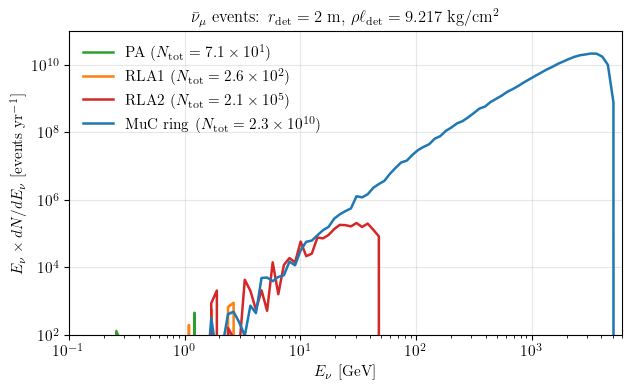

In [20]:
from mint import plot_tools as pt
fig, ax = pt.std_fig(figsize=(7, 4))
for name in machines:
    y = event_rates_far[name]["numubar"]
    dE = np.diff(energy_edges)

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    ax.plot(
        e_centers, e_centers*y, "-", lw=1.8,
        color=machine_colors[name],
        label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers*(y - yerr), 1e-30, None),
        e_centers*(y + yerr),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e2, 1e11)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 9.217$ kg/cm$^2$")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, loc='upper left', ncol=1)
# fig.savefig("plots/machine_event_rate_2zmax.pdf", dpi=300, bbox_inches="tight")

Look for $1/r^2$ behavior

PA: 1/r^2 regime begins at z ~ 587.8 m
RLA1: 1/r^2 regime begins at z ~ 412.5 m
RLA2: 1/r^2 regime begins at z ~ 2030.9 m
MuC ring: 1/r^2 regime begins at z ~ 10.0 m


/var/folders/84/k7jzjrjn68595pl9grlw_7cm0000gq/T/ipykernel_36649/2115302958.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


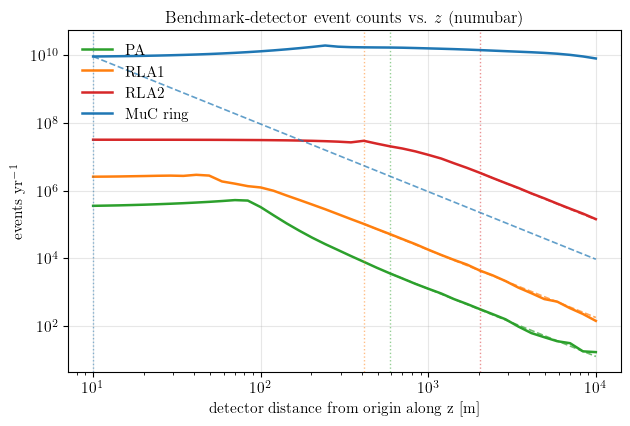

In [21]:
def plot_event_counts_vs_distance(flavor="numubar", z_range_m=(10, 1e4), n_points=40):
    """Total benchmark-detector event count as a function of detector z-distance.

    The dashed 1/z^2 reference is anchored at the first distance where the local
    log-log slope of the event-count curve is consistent with -2, i.e. where the
    geometric falloff has entered its asymptotic regime.
    """
    z_vals = np.geomspace(*z_range_m, n_points)
    rho_L_g_cm2 = 1e3
    det_radius_cm = 2e2
    det_area_cm2 = np.pi * det_radius_cm**2
    nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g

    counts_by_machine = {}
    onset_by_machine = {}
    for name in machines:
        counts = []
        for z_det_m in z_vals:
            det_location = np.array([0.0, 0.0, z_det_m * 1e2])  # cm
            _, flux = sims[name][flavor].get_flux_at_generic_location(
                det_location=det_location,
                det_radius=det_radius_cm,
                ebins=energy_edges,
                per_cm2=True,
                normalization=bunches_per_year,
            )
            dN_dE = (
                flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                * nucleon_column_density
            )
            counts.append(np.sum(dN_dE * np.diff(energy_edges)))
        counts_by_machine[name] = np.asarray(counts)

        y = counts_by_machine[name]
        valid = np.isfinite(y) & (y > 0)
        if valid.sum() < 3:
            onset_idx = 0
        else:
            z_fit = z_vals[valid]
            y_fit = y[valid]
            logz = np.log10(z_fit)
            logy = np.log10(y_fit)
            slope = np.gradient(logy, logz)
            idx = np.where(np.abs(slope + 2.0) < 0.1)[0]
            onset_idx = int(idx[0]) if idx.size else 0

        onset_by_machine[name] = z_vals[valid][onset_idx]

    fig, ax = pt.std_fig(figsize=(7, 4.5))
    for name in machines:
        y = counts_by_machine[name]
        ax.plot(
            z_vals,
            y,
            "-",
            lw=1.8,
            color=machine_colors[name],
            label=name,
        )

        z0 = onset_by_machine[name]
        y0 = np.interp(z0, z_vals, y)
        mask = z_vals >= z0
        if np.any(mask):
            ax.plot(
                z_vals[mask],
                y0 * (z0 / z_vals[mask]) ** 2,
                "--",
                color=machine_colors[name],
                lw=1.2,
                alpha=0.7,
            )
            ax.axvline(z0, color=machine_colors[name], ls=":", lw=1.0, alpha=0.5)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("detector distance from origin along z [m]")
    ax.set_ylabel(r"events yr$^{-1}$")
    ax.set_title(rf"Benchmark-detector event counts vs. $z$ ({flavor})")
    ax.grid(True, which="major", ls="-", alpha=0.3)
    ax.legend(frameon=False, fontsize=11, loc="upper left")
    fig.tight_layout()
    return fig, ax, z_vals, counts_by_machine, onset_by_machine


fig, ax, z_vals, counts_by_machine, onset_by_machine = plot_event_counts_vs_distance(flavor="numubar")
for name, z0 in onset_by_machine.items():
    print(f"{name}: 1/r^2 regime begins at z ~ {z0:.1f} m")
fig.savefig("plots/machine_event_counts_vs_distance.pdf", dpi=300, bbox_inches="tight")


Look at event rate at the asymptotic behavior start

In [22]:
# Detector: rho * L = 1 kg/cm^2, r = 2 m, at z_det = z0 from the asymptotic 1/r^2 onset
rho_L_g_cm2 = 1e3                      # rho * L = 1 kg/cm^2
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 2e2                       # cm
det_area_cm2 = np.pi * det_radius**2

e_centers = np.sqrt(energy_edges[1:] * energy_edges[:-1])
u_fine = np.linspace(0, 1, 5000)

# asymptotic event rates at the onset of the 1/r^2 regime
event_rates_asymp, det_z_m = {}, {}
for name, cfg in machines.items():
    z0 = onset_by_machine[name]
    det_loc = np.array([0.0, 0.0, z0 * 1e2])
    det_z_m[name] = z0
    event_rates_asymp[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates_asymp[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m): "
              f"{flavor} {total:.4g} events / year")

# same, but with the detector moved 1 km downstream of the asymptotic onset
event_rates_asymp2, det_z_m = {}, {}
for name, cfg in machines.items():
    z0 = onset_by_machine[name]
    det_loc = np.array([0.0, 0.0, (z0+1000) * 1e2])
    det_z_m[name] = z0+200
    event_rates_asymp2[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates_asymp2[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m): "
              f"{flavor} {total:.4g} events / year")

# same, but with the detector moved to the end of each machine (z = z_max)
event_rates_at_end, det_z_m = {}, {}
for name, cfg in machines.items():
    z_extent = float(np.max(cfg["lattice"].z(u_fine)))
    det_loc = np.array([0.0, 0.0, z_extent])
    det_z_m[name] = det_loc[2] * 1e-2
    event_rates_at_end[name] = {}
    for flavor in ["numubar", "nue"]:
        _, flux = sims[name][flavor].get_flux_at_generic_location(
            det_location=det_loc,
            det_radius=det_radius,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        dN_dE = (flux * det_area_cm2 * sigma_total_lowE(flavor)(e_centers)
                 * nucleon_column_density)
        event_rates_at_end[name][flavor] = dN_dE
        total = np.sum(dN_dE * np.diff(energy_edges))
        print(f"{name} (detector at z = {det_z_m[name]:.0f} m): "
              f"{flavor} {total:.4g} events / year")

PA (detector at z = 588 m): numubar 3570 events / year
PA (detector at z = 588 m): nue 6059 events / year
RLA1 (detector at z = 412 m): numubar 1.03e+05 events / year
RLA1 (detector at z = 412 m): nue 1.718e+05 events / year
RLA2 (detector at z = 2031 m): numubar 3.353e+06 events / year
RLA2 (detector at z = 2031 m): nue 5.877e+06 events / year
MuC ring (detector at z = 10 m): numubar 9.274e+09 events / year
MuC ring (detector at z = 10 m): nue 1.332e+10 events / year
PA (detector at z = 788 m): numubar 500.6 events / year
PA (detector at z = 788 m): nue 775.1 events / year
RLA1 (detector at z = 612 m): numubar 9046 events / year
RLA1 (detector at z = 612 m): nue 1.504e+04 events / year
RLA2 (detector at z = 2231 m): numubar 1.526e+06 events / year
RLA2 (detector at z = 2231 m): nue 2.7e+06 events / year
MuC ring (detector at z = 210 m): numubar 1.61e+10 events / year
MuC ring (detector at z = 210 m): nue 2.311e+10 events / year
PA (detector at z = 80 m): numubar 5.494e+05 events / yea

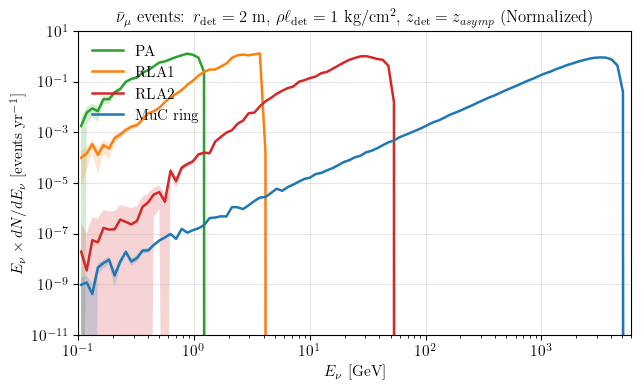

In [23]:
fig, ax = pt.std_fig(figsize=(7, 4))
for name in machines:
    y = event_rates_asymp[name]["numubar"]
    dE = np.diff(energy_edges)

    # Poisson uncertainty per bin: N_bin = (dN/dE) * dE
    n_bin = y * dE
    yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
    total = np.sum(n_bin)

    y_norm = y / total
    yerr_norm = yerr / total

    ax.plot(
        e_centers, e_centers*y_norm, "-", lw=1.8,
        color=machine_colors[name],
        # label=rf"{name} ($N_{{\rm tot}} = {pt.sci_notation(total, precision=1, notex=True)}$)"
        label=rf"{name}"
    )
    ax.fill_between(
        e_centers,
        np.clip(e_centers*(y_norm - yerr_norm), 1e-30, None),
        e_centers*(y_norm + yerr_norm),
        color=machine_colors[name],
        alpha=0.20,
        linewidth=0,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
# ax.set_ylim(1e2, 1e11)
ax.set_ylim(1e-11, 1e1)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(r"$\bar\nu_\mu$ events: $r_{\rm det} = 2$ m, "
             r"$\rho \ell_{\rm det} = 1$ kg/cm$^2$, $z_{\rm det} = z_{asymp}$ (Normalized)")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, fontsize=11, loc='upper left', ncol=1)
# fig.savefig("plots/machine_event_rate_2zmax.pdf", dpi=300, bbox_inches="tight")

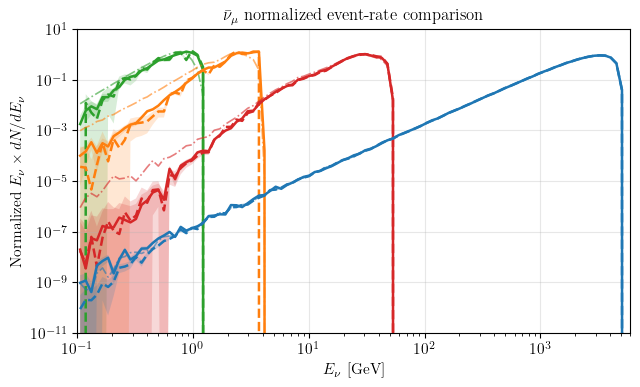

In [24]:
fig, ax = pt.std_fig(figsize=(7, 4))
style_map = {
    "original": {"ls": "-.", "label": r"at $z = z_{\rm max}$"},
    "z_asymp": {"ls": "-", "label": r"$z = z_{\rm asymp}$"},
    "z_asymp_plus_1000m": {"ls": "--", "label": r"$z = z_{\rm asymp} + 1000$ m"},
}

for name in machines:
    # original rates, normalized for direct shape comparison
    y_orig = event_rates_at_end[name]["numubar"]
    dE = np.diff(energy_edges)
    n_bin_orig = y_orig * dE
    total_orig = np.sum(n_bin_orig)
    y_orig_norm = y_orig / total_orig

    ax.plot(
        e_centers,
        e_centers * y_orig_norm,
        "-.",
        lw=1.2,
        color=machine_colors[name],
        alpha=0.6,
        label=rf"{name} (original)",
    )

    # normalized comparison curves for the asymptotic onset distances
    for key, cfg in style_map.items():
        if key == "original":
            continue
        rates = event_rates_asymp[name]["numubar"] if key == "z_asymp" else event_rates_asymp2[name]["numubar"]

        n_bin = rates * dE
        yerr = np.sqrt(np.clip(n_bin, 0.0, None)) / dE
        total = np.sum(n_bin)

        y_norm = rates / total
        yerr_norm = yerr / total

        ax.plot(
            e_centers,
            e_centers * y_norm,
            cfg["ls"],
            lw=1.8,
            color=machine_colors[name],
            label=rf"{name} ({cfg['label']})",
        )
        ax.fill_between(
            e_centers,
            np.clip(e_centers * (y_norm - yerr_norm), 1e-30, None),
            np.clip(e_centers * (y_norm + yerr_norm), 1e-30, None),
            color=machine_colors[name],
            alpha=0.18,
            linewidth=0,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 6e3)
ax.set_ylim(1e-11, 1e1)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"Normalized $E_\nu \times dN/dE_\nu$")
ax.set_title(r"$\bar\nu_\mu$ normalized event-rate comparison")
ax.grid(True, which="major", ls="-", alpha=0.3)
# ax.legend(frameon=False, fontsize=9, loc='upper left', ncol=1)

## 8. RLA2 flavor oscillations

Propagate the RLA2 beam to the DUNE-like baseline using three-flavor vacuum oscillations. Replace the values in `nufit` with the NuFIT best fit (or a sampled parameter point). We're going to assume that after the asymptotic behavior kicks in the shape of the spectrum stays the same and we can simply scale as needed

In [25]:
# NuFIT inputs: replace these numbers with the NuFIT release you want to use.
nufit = {
    "theta12_deg": 33.68,
    "theta13_deg": 8.56,
    "theta23_deg": 43.3,
    "delta_cp_deg": 212.0,
    "dm21_eV2": 7.49e-5,
    "dm31_eV2": 2.513e-3,
}


def pmns_matrix(params):
    """PDG-convention PMNS matrix, including the Dirac CP phase."""
    t12, t13, t23, delta = np.deg2rad([
        params["theta12_deg"], params["theta13_deg"],
        params["theta23_deg"], params["delta_cp_deg"],
    ])
    s12, c12 = np.sin(t12), np.cos(t12)
    s13, c13 = np.sin(t13), np.cos(t13)
    s23, c23 = np.sin(t23), np.cos(t23)
    phase = np.exp(1j * delta)
    return np.array([
        [c12 * c13, s12 * c13, s13 / phase],
        [-s12 * c23 - c12 * s23 * s13 * phase,
         c12 * c23 - s12 * s23 * s13 * phase, s23 * c13],
        [s12 * s23 - c12 * c23 * s13 * phase,
         -c12 * s23 - s12 * c23 * s13 * phase, c23 * c13],
    ])


def oscillation_probabilities(E_GeV, baseline_km, params, antineutrino=False):
    """Return P[detected flavor, initial flavor, energy] in vacuum.

    The einsum below builds A[b, a] = sum_i U_bi U*_ai exp(-i m_i^2 L / 2E),
    the amplitude for a -> b, so the *first* index is the DETECTED flavor.
    With delta_CP != 0, P(a -> b) != P(b -> a), so the order matters.
    """
    energies = np.asarray(E_GeV, dtype=float)
    if np.any(energies <= 0):
        raise ValueError("oscillation energies must be positive")
    U = pmns_matrix(params)
    if antineutrino:
        U = U.conj()
    mass2 = np.array([0.0, params["dm21_eV2"], params["dm31_eV2"]])
    phase = np.exp(-2j * 1.267 * mass2[:, None] * baseline_km / energies[None, :])
    amplitude = np.einsum("bi,ai,ie->bae", U, U.conj(), phase)
    return np.abs(amplitude) ** 2

RLA2 detected nue: 3.623e+05 events / year
RLA2 detected numu: 797 events / year
RLA2 detected nutau: 1098 events / year
RLA2 detected nuebar: 342.3 events / year
RLA2 detected numubar: 1.979e+05 events / year
RLA2 detected nutaubar: 8320 events / year
nue: oscillated channels sum to 3.642e+05 vs section 7 direct 3.544e+05 events/yr (ratio 1.028)
numubar: oscillated channels sum to 2.066e+05 vs section 7 direct 2.064e+05 events/yr (ratio 1.001)


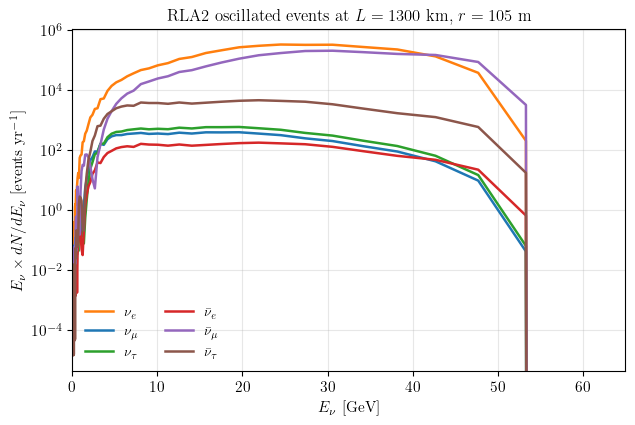

In [ ]:
rho_L_g_cm2 = 9.2176e3
nucleon_column_density = rho_L_g_cm2 / const.m_proton_in_g
det_radius = 105e2                       # cm
det_area_cm2 = np.pi * det_radius**2


# onset_by_machine is in METRES (section 7 z axis) -- convert to km.
flux_ref_km = onset_by_machine["RLA2"] * 1e-3   # 1/r^2 onset, where the MC flux is sampled
rla2_baseline_km = 1300                  # oscillation baseline; raise this and the flux below is scaled geometrically to match
                                           
osc_detector_area = np.pi * det_radius**2   # far detector, AT the baseline

# The SAMPLING face at r_ref is a different thing from the far detector.
# get_flux_at_generic_location returns the flux AVERAGED over the face, so a face
# wider than the beam spot averages in empty space and dilutes the answer.  The
# spot is only ~6 m across at 2 km (1/gamma = 1.7 mrad at p_mu = 63 GeV), so
# sample with the 2 m benchmark face to get the on-axis flux, then scale that
# per-cm^2 value out to the baseline -- where the 105 m detector sits deep inside
# a ~4 km spot and likewise sees the on-axis value.

flux_ref_radius = det_radius * (flux_ref_km / rla2_baseline_km)                     # cm

rla2_flux = {}
for source in ("nue", "numubar"):
    _, rla2_flux[source] = sims["RLA2"][source].get_flux_at_generic_location(
        det_location=flux_ref_km * 1e5 * np.array([0.0, 0.0, 1.0]),
        det_radius=flux_ref_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=bunches_per_year,
    )
    # shape assumed frozen past the 1/r^2 onset, so only the normalization moves
    rla2_flux[source] = rla2_flux[source] * (flux_ref_km / rla2_baseline_km) ** 2

P_nu = oscillation_probabilities(e_centers, rla2_baseline_km, nufit)
P_nubar = oscillation_probabilities(
    e_centers, rla2_baseline_km, nufit, antineutrino=True
)
assert np.allclose(P_nu.sum(axis=0), 1.0, atol=1e-9), "P not unitary"

initial_flavors = ("e", "mu", "tau")
flux_by_detected = {}
for i, flavor in enumerate(initial_flavors):
    # P[detected, initial]: the mu+ beam starts as nu_e + nubar_mu
    flux_by_detected[f"nu{flavor}"] = rla2_flux["nue"] * P_nu[i, 0]
    flux_by_detected[f"nu{flavor}bar"] = rla2_flux["numubar"] * P_nubar[i, 1]


def sigma_for_detected_flavor(energy, flavor, E0=50.0):
    """Total (CC + NC) DIS cross section for one detected neutrino species.

    The tabulated DIS pieces return exactly 0 below E0 = 50 GeV, which is above
    most of the RLA2 spectrum (p_mu <= 63 GeV).  As in `sigma_total_lowE`
    (section 4) we fall back on the sigma ~ E DIS scaling there.  The tau CC
    threshold factor multiplies the CC part only, not NC.
    """
    E = np.asarray(energy, dtype=float)
    antineutrino = flavor.endswith("bar")
    tag = "numubar" if antineutrino else "numu"   # DIS is flavor-universal here

    def _lowE(fn):
        return np.where(E >= E0, fn(E), float(fn(E0)) * E / E0)

    total = _lowE(xsecs.total_xsecs[tag])
    if flavor.startswith("nutau"):
        cc = _lowE(lambda x: xsecs.sigma_CC(x, tag))
        return cc * xsecs.tau_threshold_factor(E) + (total - cc)
    return total


osc_event_rates = {
    flavor: flux * osc_detector_area
    * sigma_for_detected_flavor(e_centers, flavor) * nucleon_column_density
    for flavor, flux in flux_by_detected.items()
}

flavor_labels = {
    "nue": r"$\nu_e$", "numu": r"$\nu_\mu$", "nutau": r"$\nu_\tau$",
    "nuebar": r"$\bar\nu_e$", "numubar": r"$\bar\nu_\mu$", "nutaubar": r"$\bar\nu_\tau$",
}
flavor_colors = {
    "nue": "tab:orange", "numu": "tab:blue", "nutau": "tab:green",
    "nuebar": "tab:red", "numubar": "tab:purple", "nutaubar": "tab:brown",
}
fig, ax = pt.std_fig(figsize=(7, 4.5))
for flavor in flavor_labels:
    y = osc_event_rates[flavor]
    total = np.sum(y * np.diff(energy_edges))
    print(f"RLA2 detected {flavor}: {total:.4g} events / year")
    ax.plot(e_centers, e_centers * y, lw=1.8, color=flavor_colors[flavor],
            label=flavor_labels[flavor])
# ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0,65)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu \times dN/dE_\nu$ [events yr$^{-1}$]")
ax.set_title(rf"RLA2 oscillated events at $L = {rla2_baseline_km:.4g}$ km, $r = {det_radius/100:.0f}$ m")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, ncol=2)
fig.savefig("plots/rla2_oscillated_event_rates.pdf", dpi=300, bbox_inches="tight")

# Guard against exactly the sampling-face mistake above: DIS is flavor-universal
# here (bar the tau CC threshold), so by unitarity the oscillated channels must sum
# back to the unoscillated rate section 7 computed directly at 1300 km.
dE = np.diff(energy_edges)
for born, sector in (("nue", ("nue", "numu", "nutau")),
                     ("numubar", ("nuebar", "numubar", "nutaubar"))):
    extrapolated = sum(np.sum(osc_event_rates[f] * dE) for f in sector)
    direct = np.sum(event_rates_far["RLA2"][born] * dE)
    print(f"{born}: oscillated channels sum to {extrapolated:.4g} vs "
          f"section 7 direct {direct:.4g} events/yr (ratio {extrapolated/direct:.3f})")


Stacked per-flavor view of the oscillated spectra: one panel per flavor, linear
axes, solid for neutrinos and dashed for antineutrinos. The black curves are the
unoscillated references from section 7, computed directly at 1300 km in this same
far detector.

Note that the $\mu^+$ beam is born as $\nu_e + \bar\nu_\mu$, so those are the only
two unoscillated spectra that exist -- $\bar\nu_e$ and $\nu_\mu$ are identically
zero at $L = 0$ and appear only through oscillation.

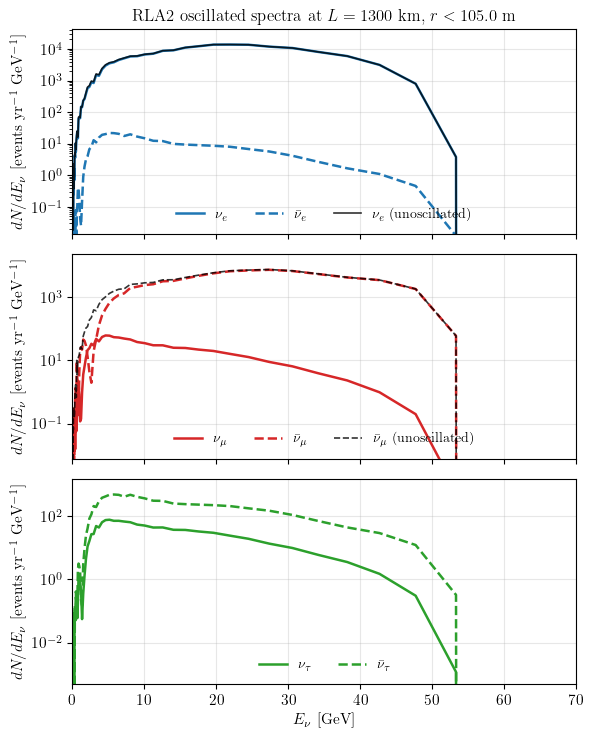

In [27]:
# Stacked per-flavor spectra: linear in E, log in dN/dE, everything on one axis.
#
# Reference curves: the mu+ beam starts as nu_e + nubar_mu, so the unoscillated
# spectra are nu_e (top panel, solid black) and nubar_mu (middle, dashed black) --
# each in that panel's neutrino/antineutrino linestyle.  There is no unoscillated
# nubar_e or nu_mu to draw; both are zero at production.
#
# The reference is built from rla2_flux -- the 2 km sample already scaled out to
# the baseline in the cell above -- so it rests on the same MC statistics as the
# oscillated curves and their ratio is exactly the survival probability.
#
# NOT event_rates_far["RLA2"]: that is section 7's direct calculation at 1300 km
# and agrees on average, but get_flux_at_generic_location keeps a decay only if
# the neutrino passes within det_radius of the detector point, and out there that
# is 0.2% of the sample against 34% at the 2 km sampling point -- far too spiky.
# Cell 34's ratio print keeps it as the independent cross-check.

panels = (
    ("e",   "tab:blue",  r"$\nu_e$",    r"$\bar\nu_e$"),
    ("mu",  "tab:red",   r"$\nu_\mu$",  r"$\bar\nu_\mu$"),
    ("tau", "tab:green", r"$\nu_\tau$", r"$\bar\nu_\tau$"),
)
unoscillated = {
    "e":  ("nue",     "-",  r"$\nu_e$ (unoscillated)"),
    "mu": ("numubar", "--", r"$\bar\nu_\mu$ (unoscillated)"),
}

e_max_gev = 70.0                      # RLA2 tops out at p_mu = 63 GeV
mask = e_centers <= e_max_gev
y_decades = 6                         # how far below each panel's peak to show

unosc_event_rates = {
    born: rla2_flux[born] * osc_detector_area
    * sigma_for_detected_flavor(e_centers, born) * nucleon_column_density
    for born in ("nue", "numubar")
}

fig, axes = plt.subplots(3, 1, figsize=(6.5, 8.5), sharex=True)
fig.subplots_adjust(hspace=0.10)

for ax, (flav, color, lab_nu, lab_nubar) in zip(axes, panels):
    curves = []
    for key, ls, lab in ((f"nu{flav}", "-", lab_nu), (f"nu{flav}bar", "--", lab_nubar)):
        curves.append(osc_event_rates[key][mask])
        ax.plot(e_centers[mask], curves[-1], ls, lw=1.8, color=color, label=lab)

    if flav in unoscillated:
        born, ls, lab = unoscillated[flav]
        curves.append(unosc_event_rates[born][mask])
        ax.plot(e_centers[mask], curves[-1], ls, lw=1.2, color="black",
                alpha=0.8, label=lab)

    peak = max(np.max(c) for c in curves)
    ax.set_yscale("log")
    ax.set_ylim(peak * 10.0**(-y_decades), peak * 3.0)
    ax.set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
    ax.grid(True, which="major", ls="-", alpha=0.3)
    ax.legend(frameon=False, fontsize=10, loc="lower center", ncol=3)

axes[0].set_xlim(0.0, e_max_gev)
axes[-1].set_xlabel(r"$E_\nu$ [GeV]")
axes[0].set_title(rf"RLA2 oscillated spectra at $L = {rla2_baseline_km:.4g}$ km, "
                  rf"$r < {det_radius * 1e-2:.1f}$ m")
fig.savefig("plots/rla2_oscillated_spectra_by_flavor.pdf", dpi=300,
            bbox_inches="tight")


### The same study for PA and RLA1

Each machine gets its own reference distance -- the $1/r^2$ onset found in cell 27
-- and its own sampling face, since the beam opening angle $\sim m_\mu / p$ differs
by a factor of ~50 between PA and RLA2. The flux is sampled there and scaled out to
the same 1300 km baseline and far detector as RLA2.

For PA this is the *only* way to get a number: section 7's direct calculation at
1300 km returns literally zero $\bar\nu_\mu$ events, because no MC decay survives
the geometric acceptance cut at that distance.

--- PA: flux sampled at 588 m with a 24.8 m face, scaled to 1300 km ---
    nue       22.43 events / year
    numu      0.8767 events / year
    nutau     0.4197 events / year
    nuebar    0.4297 events / year
    numubar   6.267 events / year
    nutaubar  1.939 events / year
    nue: channels sum to 23.73 vs section 7 direct 28.69 events/yr (ratio 0.827)
    numubar: channels sum to 8.636 vs section 7 direct 70.51 events/yr (ratio 0.122)
--- RLA1: flux sampled at 412 m with a 4.4 m face, scaled to 1300 km ---
    nue       363.8 events / year
    numu      10.47 events / year
    nutau     6.744 events / year
    nuebar    6.372 events / year
    numubar   51.17 events / year
    nutaubar  83.23 events / year
    nue: channels sum to 381.1 vs section 7 direct 291.6 events/yr (ratio 1.307)
    numubar: channels sum to 140.8 vs section 7 direct 261.2 events/yr (ratio 0.539)


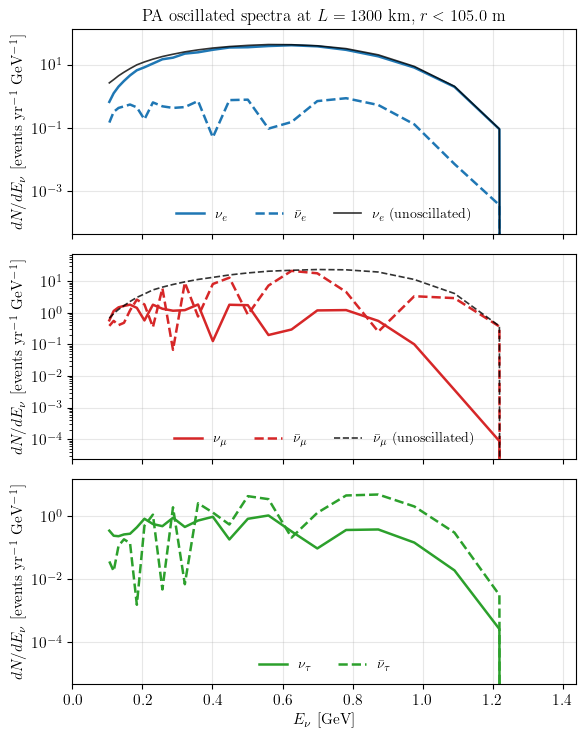

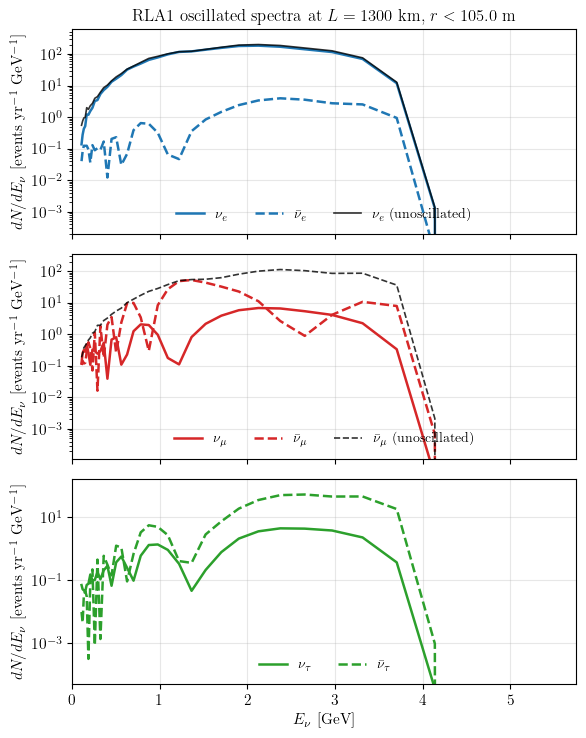

In [28]:
# Section 8 repeated for the lower-energy machines.
#
# Needs cells 33-34 to have run: nufit, oscillation_probabilities,
# sigma_for_detected_flavor, osc_detector_area, nucleon_column_density.
#
# CAVEAT for PA: its neutrinos are sub-GeV, where sigma_for_detected_flavor is a
# linear extrapolation of the DIS table (see the note on sigma_total_lowE in
# section 4).  The real QE/RES cross section differs there, so PA rates are an
# order-of-magnitude estimate only.

def sampling_radius_cm(name, r_ref_cm, frac=0.5):
    """Radius of the face used to sample the flux at r_ref.

    It has to be small against the beam spot (so we read the on-axis flux, which is
    what scales as 1/r^2) but not so small that the geometric acceptance starves the
    MC.  Fixing it at a fraction of the characteristic opening angle m_mu / p keeps
    the accepted fraction ~frac^2 for every machine, whose angles differ by ~50x.
    """
    theta = const.m_mu / machines[name]["p_range"][1]
    return frac * theta * r_ref_cm


def oscillated_rates(name, baseline_km, frac=0.5):
    """Sample at the machine's 1/r^2 onset, scale to baseline_km, then oscillate."""
    r_ref_m = onset_by_machine[name]
    r_ref_km = r_ref_m * 1e-3
    r_sample = sampling_radius_cm(name, r_ref_m * 1e2, frac)

    flux = {}
    for source in ("nue", "numubar"):
        _, f = sims[name][source].get_flux_at_generic_location(
            det_location=r_ref_km * 1e5 * np.array([0.0, 0.0, 1.0]),
            det_radius=r_sample,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        flux[source] = f * (r_ref_km / baseline_km) ** 2   # shape frozen, norm moves

    P_nu = oscillation_probabilities(e_centers, baseline_km, nufit)
    P_nubar = oscillation_probabilities(e_centers, baseline_km, nufit,
                                        antineutrino=True)

    def to_rate(f, flavor):
        return (f * osc_detector_area
                * sigma_for_detected_flavor(e_centers, flavor)
                * nucleon_column_density)

    osc = {}
    for i, fl in enumerate(("e", "mu", "tau")):
        osc[f"nu{fl}"] = to_rate(flux["nue"] * P_nu[i, 0], f"nu{fl}")
        osc[f"nu{fl}bar"] = to_rate(flux["numubar"] * P_nubar[i, 1], f"nu{fl}bar")
    unosc = {b: to_rate(flux[b], b) for b in ("nue", "numubar")}
    return osc, unosc, r_ref_km, r_sample


def plot_flavor_stack(name, osc, unosc, baseline_km, e_max_gev, y_decades=6):
    """Cell 36's stacked per-flavor figure, for an arbitrary machine."""
    panels = (
        ("e",   "tab:blue",  r"$\nu_e$",    r"$\bar\nu_e$"),
        ("mu",  "tab:red",   r"$\nu_\mu$",  r"$\bar\nu_\mu$"),
        ("tau", "tab:green", r"$\nu_\tau$", r"$\bar\nu_\tau$"),
    )
    unoscillated = {
        "e":  ("nue",     "-",  r"$\nu_e$ (unoscillated)"),
        "mu": ("numubar", "--", r"$\bar\nu_\mu$ (unoscillated)"),
    }
    mask = e_centers <= e_max_gev

    fig, axes = plt.subplots(3, 1, figsize=(6.5, 8.5), sharex=True)
    fig.subplots_adjust(hspace=0.10)

    for ax, (flav, color, lab_nu, lab_nubar) in zip(axes, panels):
        curves = []
        for key, ls, lab in ((f"nu{flav}", "-", lab_nu),
                             (f"nu{flav}bar", "--", lab_nubar)):
            curves.append(osc[key][mask])
            ax.plot(e_centers[mask], curves[-1], ls, lw=1.8, color=color, label=lab)

        if flav in unoscillated:
            born, ls, lab = unoscillated[flav]
            curves.append(unosc[born][mask])
            ax.plot(e_centers[mask], curves[-1], ls, lw=1.2, color="black",
                    alpha=0.8, label=lab)

        peak = max(np.max(c) for c in curves)
        if peak > 0:
            ax.set_yscale("log")
            ax.set_ylim(peak * 10.0 ** (-y_decades), peak * 3.0)
        ax.set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
        ax.grid(True, which="major", ls="-", alpha=0.3)
        ax.legend(frameon=False, fontsize=10, loc="lower center", ncol=3)

    axes[0].set_xlim(0.0, e_max_gev)
    axes[-1].set_xlabel(r"$E_\nu$ [GeV]")
    axes[0].set_title(rf"{name} oscillated spectra at $L = {baseline_km:.4g}$ km, "
                      rf"$r < {det_radius * 1e-2:.1f}$ m")
    slug = name.lower().replace(" ", "_")
    fig.savefig(f"plots/{slug}_oscillated_spectra_by_flavor.pdf", dpi=300,
                bbox_inches="tight")
    return fig


dE = np.diff(energy_edges)
for name in ("PA", "RLA1"):
    osc, unosc, r_ref_km, r_sample = oscillated_rates(name, rla2_baseline_km)
    print(f"--- {name}: flux sampled at {r_ref_km * 1e3:.0f} m with a "
          f"{r_sample * 1e-2:.1f} m face, scaled to {rla2_baseline_km:.4g} km ---")
    for flavor in ("nue", "numu", "nutau", "nuebar", "numubar", "nutaubar"):
        print(f"    {flavor:9s} {np.sum(osc[flavor] * dE):.4g} events / year")
    # cross-check against section 7's direct calculation, where it has any statistics
    for born, sector in (("nue", ("nue", "numu", "nutau")),
                         ("numubar", ("nuebar", "numubar", "nutaubar"))):
        direct = np.sum(event_rates_far[name][born] * dE)
        total = sum(np.sum(osc[f] * dE) for f in sector)
        ratio = f"{total / direct:.3f}" if direct > 0 else "n/a (direct MC is empty)"
        print(f"    {born}: channels sum to {total:.4g} vs section 7 direct "
              f"{direct:.4g} events/yr (ratio {ratio})")

    plot_flavor_stack(name, osc, unosc, rla2_baseline_km,
                      e_max_gev=machines[name]["p_range"][1] * 1.15)


## 9. Export the oscillated flux for GENIE

Write the section-8 spectra out as GENIE flux histograms, so the interactions can be
generated with real nuclear physics on argon instead of the flat
$\sigma \times \rho\ell$ estimate used everywhere above. `mint.genie_tools` does the
writing; the physics decisions are here.

Two things change relative to section 8, both forced by how GENIE reads a flux:

- **Uniform bins.** GENIE samples the histogram with ROOT's `TH1::GetRandom()`, which
  treats each bin's content as that bin's probability and never divides by the bin
  width. On the log-spaced grid used everywhere above that misrepresents a density;
  on a uniform grid the two agree up to a constant. (Recent GENIE detects a
  variable-width axis and folds the widths in for you, older builds do not -- a
  uniform grid is correct either way.)
- **Oscillate on the fine grid.** At $L = 1300$ km the $L/E$ wiggles are narrower than
  a 12%-wide log bin below $\sim 10$ GeV. So the *unoscillated* flux is resampled
  first, while it is still smooth, and $P(E)$ is evaluated at the fine bin centers
  afterwards -- never the other way round.

GENIE keeps only the *shape* of the flux, so the normalization has to travel
separately. The JSON sidecar written next to each ROOT file records, per flavor, the
flux integral, the events/year this notebook predicts, and hence what a single
generated event is worth.

In [29]:
# Section 8's oscillated spectra, written out as GENIE flux histograms.
#
# Needs cells 33-38 to have run: nufit, oscillation_probabilities,
# sigma_for_detected_flavor, sampling_radius_cm, onset_by_machine,
# osc_detector_area, nucleon_column_density, det_radius, rho_L_g_cm2.
import os

from mint import genie_tools as gt

GENIE_DIR = "data/genie"
os.makedirs(GENIE_DIR, exist_ok=True)

# One uniform grid per machine. The bin has to be narrower than an oscillation
# wiggle, whose width in energy is ~ pi E^2 / (1.267 dm31 L) -- 0.07 GeV at
# E = 0.3 GeV against 5 GeV at E = 60 GeV, so the sub-GeV machines need much
# finer bins than RLA2 does. Each grid runs to just past its machine's endpoint
# momentum.
genie_grids = {
    "PA":   {"e_max": 1.5,  "bin_width": 0.0025},
    "RLA1": {"e_max": 6.0,  "bin_width": 0.01},
    "RLA2": {"e_max": 70.0, "bin_width": 0.1},
}


def export_for_genie(name, baseline_km=rla2_baseline_km, frac=0.5, n_events=100_000):
    """Sample a machine's flux at its 1/r^2 onset, scale it out to the baseline,
    oscillate it on the uniform GENIE grid, and write the flux file.

    Same construction as `oscillated_rates` in cell 38 -- the same sampling face,
    the same geometric scaling, the same frozen shape past the onset -- except
    that the oscillation probabilities are evaluated on the fine grid rather than
    on the 100 log bins used for the figures.
    """
    grid = genie_grids[name]
    edges = gt.uniform_energy_edges(grid["e_max"], grid["bin_width"])
    centers = 0.5 * (edges[1:] + edges[:-1])

    r_ref_m = onset_by_machine[name]
    r_ref_km = r_ref_m * 1e-3
    r_sample = sampling_radius_cm(name, r_ref_m * 1e2, frac)

    # Unoscillated flux at the sampling face, scaled to the baseline, moved onto
    # the GENIE grid while it is still a smooth spectrum.
    born = {}
    for source in ("nue", "numubar"):
        _, f = sims[name][source].get_flux_at_generic_location(
            det_location=r_ref_km * 1e5 * np.array([0.0, 0.0, 1.0]),
            det_radius=r_sample,
            ebins=energy_edges,
            per_cm2=True,
            normalization=bunches_per_year,
        )
        born[source] = gt.resample_flux(
            energy_edges, f * (r_ref_km / baseline_km) ** 2, edges
        )

    P_nu = oscillation_probabilities(centers, baseline_km, nufit)
    P_nubar = oscillation_probabilities(centers, baseline_km, nufit, antineutrino=True)

    # P[detected, initial]: the mu+ beam starts as nu_e + nubar_mu
    fluxes = {}
    for i, fl in enumerate(("e", "mu", "tau")):
        fluxes[f"nu{fl}"] = born["nue"] * P_nu[i, 0]
        fluxes[f"nu{fl}bar"] = born["numubar"] * P_nubar[i, 1]

    rates = {
        flavor: flux * osc_detector_area
        * sigma_for_detected_flavor(centers, flavor) * nucleon_column_density
        for flavor, flux in fluxes.items()
    }

    return gt.export_flux(
        os.path.join(GENIE_DIR, f"{name.lower()}_dune_flux.root"),
        edges,
        fluxes,
        event_rates=rates,
        new_edges=edges,       # already on the GENIE grid: nothing to resample
        target=gt.AR40,
        n_events=n_events,
        metadata={
            "machine": name,
            "beam": "mu+ (born as nu_e + nubar_mu)",
            "baseline_km": baseline_km,
            "flux_sampled_at_km": r_ref_km,
            "sampling_face_radius_cm": r_sample,
            "detector_radius_cm": det_radius,
            "detector_column_density_g_cm2": rho_L_g_cm2,
            "target_nucleons": nucleon_column_density * osc_detector_area,
            "bunches_per_year": bunches_per_year,
            "oscillation_parameters": nufit,
            "caveat": (
                "events_per_year and weight_per_event use mint.xsecs' DIS tables, "
                "linearly extrapolated below their 50 GeV edge (see section 4). "
                "GENIE computes the cross section properly, so normalizing through "
                "flux_integral x <sigma>_GENIE x target_nucleons is the better route."
            ),
        },
    )


exports = {}
for name in ("PA", "RLA1", "RLA2"):
    exports[name] = export_for_genie(name)
    print(f"===== {name} =====")
    gt.print_summary(exports[name])
    print()

===== PA =====
wrote data/genie/pa_dune_flux.root
      data/genie/pa_dune_flux.json
grid: 600 uniform bins, 0-1.5 GeV (0.0025 GeV wide)

   flavor  PDG   flux [/cm2/yr]    frac    events/yr    wt/event
----------------------------------------------------------------
      nue   12       2.5027e+03  0.4276   2.2158e+01   2.216e-04
   nuebar  -12       1.1721e+02  0.0200   4.2061e-01   4.206e-06
     numu   14       1.4218e+02  0.0243   8.5310e-01   8.531e-06
  numubar  -14       1.3298e+03  0.2272   6.1849e+00   6.185e-05
    nutau   16       2.7318e+02  0.0467   4.2192e-01   4.219e-06
 nutaubar  -16       1.4875e+03  0.2542   1.9111e+00   1.911e-05

===== RLA1 =====
wrote data/genie/rla1_dune_flux.root
      data/genie/rla1_dune_flux.json
grid: 600 uniform bins, 0-6 GeV (0.01 GeV wide)

   flavor  PDG   flux [/cm2/yr]    frac    events/yr    wt/event
----------------------------------------------------------------
      nue   12       1.1731e+04  0.4678   3.5757e+02   3.576e-03
   nue

### Checking what GENIE will actually see

Read the histograms back out of the ROOT file and compare them with section 8's curves,
which were computed independently on the 100 log bins and with a slightly different
sampling face. Agreement up to MC noise means the resampling and the fine-grid
oscillation did not move the spectrum.

   flavor     exported    section 8   ratio
      nue   1.1495e+06   1.1392e+06   1.009
     numu   5.6303e+03   5.6693e+03   0.993
    nutau   9.1867e+03   9.2567e+03   0.992
   nuebar   4.2912e+03   4.3070e+03   0.996
  numubar   1.0225e+06   1.0196e+06   1.003
 nutaubar   1.2088e+05   1.2138e+05   0.996


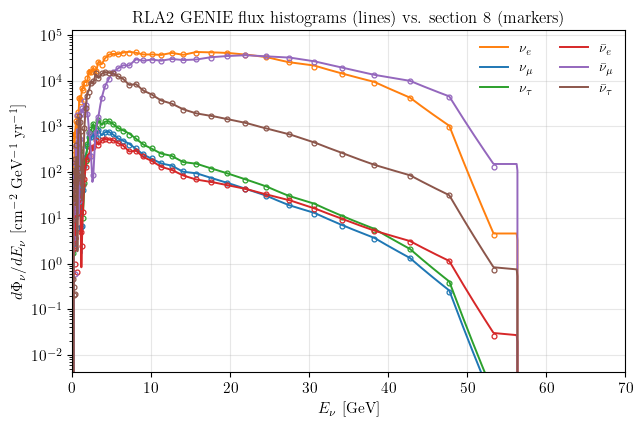

In [30]:
# Read the RLA2 file back the way GENIE will, and overlay section 8.
import uproot

with uproot.open(exports["RLA2"]["root_path"]) as f:
    exported = {flavor: f[gt.histogram_name(flavor)].to_numpy() for flavor in gt.NU_FLAVORS}

exported_edges = exported["numubar"][1]
exported_centers = 0.5 * (exported_edges[1:] + exported_edges[:-1])

fig, ax = pt.std_fig(figsize=(7, 4.5))
for flavor in flavor_labels:
    values = exported[flavor][0]
    ax.plot(exported_centers, values, lw=1.4, color=flavor_colors[flavor],
            label=flavor_labels[flavor])
    # section 8, on the coarse grid and with the 2 m sampling face
    ax.plot(e_centers, flux_by_detected[flavor], ls="none", marker="o", ms=3.5,
            mfc="none", mew=0.9, color=flavor_colors[flavor])

ax.set_yscale("log")
ax.set_xlim(0, 70)
peak = max(np.max(exported[f][0]) for f in flavor_labels)
ax.set_ylim(peak * 1e-7, peak * 3)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [cm$^{-2}$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"RLA2 GENIE flux histograms (lines) vs. section 8 (markers)")
ax.grid(True, which="major", ls="-", alpha=0.3)
ax.legend(frameon=False, ncol=2, fontsize=10)
fig.savefig("plots/rla2_genie_flux_export.pdf", dpi=300, bbox_inches="tight")

# Integrals, on the two grids. The sampling faces differ (cell 38's m_mu/p rule
# against the flat 2 m of cell 34), so a few percent is expected; a factor is not.
dE_coarse = np.diff(energy_edges)
print(f"{'flavor':>9} {'exported':>12} {'section 8':>12} {'ratio':>7}")
for flavor in flavor_labels:
    exported_total = gt.flux_integral(exported_edges, exported[flavor][0])
    section8_total = np.sum(flux_by_detected[flavor][e_centers <= 70.0]
                            * dE_coarse[e_centers <= 70.0])
    print(f"{flavor:>9} {exported_total:>12.4e} {section8_total:>12.4e} "
          f"{exported_total / section8_total:>7.3f}")

### Running GENIE

Section 10 drives these jobs from Python; the command lines below are the same
thing for running by hand.

`gevgen` takes one species per job, so the six flavors are six runs; `gevgen_t2k` is
the same histogram flux driver with all six at once, splitting events between them by
the histograms' relative normalization (which is why they are written on a shared grid
in a shared unit). Both command lines are in `exports[name]["gevgen"]` and
`exports[name]["gevgen_t2k"]`, and the cell below prints them. `gevgen` is always
built; `gevgen_t2k` only exists if GENIE was configured with `--enable-t2k`, so fall
back on the per-flavor runs if it is missing.

**Getting a rate back.** GENIE throws away the absolute normalization, so `-n N`
events mean nothing on their own. Two ways to restore the scale, both from the JSON
sidecar:

1. `weight_per_event` -- each generated event of that flavor counts as this many
   events per year. Consistent with this notebook, but it inherits the DIS
   extrapolation below 50 GeV that section 4 warns about.
2. Better, since a proper cross section is the reason to run GENIE at all:
   $N/\mathrm{yr} = \Phi \times \langle\sigma\rangle \times N_{\rm nucleons}$, with
   $\Phi$ = `flux_integral`, $N_{\rm nucleons}$ = `target_nucleons`, and
   $\langle\sigma\rangle$ the flux-averaged cross section of the generated sample
   (the mean of the per-event cross section GENIE stores in the output ntuple).

**What the histogram flux cannot do.** There are no ray directions or vertices in a
TH1: `gevgen` puts every vertex at the origin and fires along $+z$. That is enough for
an interaction sample with the right energy and flavor content. A full detector
simulation with the real beam geometry needs a ray-level flux -- `dk2nu` or `gsimple`
ntuples through `gevgen_fnal` -- which would mean writing out the individual decays
from `sims[name]` rather than a binned spectrum.

In [31]:
for name, export in exports.items():
    print(f"# ---- {name}: {export['root_path']} ----")
    print(f"# all six flavors in one job")
    print(export["gevgen_t2k"])
    print("# or one job per flavor")
    for flavor, cmd in export["gevgen"].items():
        print(cmd)
    print()

# ---- PA: data/genie/pa_dune_flux.root ----
# all six flavors in one job
gevgen_t2k -f data/genie/pa_dune_flux.root,12[flux_nue],-12[flux_nuebar],14[flux_numu],-14[flux_numubar],16[flux_nutau],-16[flux_nutaubar] -g 1000180400 -n 100000 --tune G18_02a_00_000 --cross-sections $GENIE/data/xsec.xml
# or one job per flavor
gevgen -n 100000 -p 12 -t 1000180400 -e 0,1.5025 -f data/genie/pa_dune_flux.root,flux_nue --tune G18_02a_00_000 --cross-sections $GENIE/data/xsec.xml -o gntp_nue
gevgen -n 100000 -p -12 -t 1000180400 -e 0,1.5025 -f data/genie/pa_dune_flux.root,flux_nuebar --tune G18_02a_00_000 --cross-sections $GENIE/data/xsec.xml -o gntp_nuebar
gevgen -n 100000 -p 14 -t 1000180400 -e 0,1.5025 -f data/genie/pa_dune_flux.root,flux_numu --tune G18_02a_00_000 --cross-sections $GENIE/data/xsec.xml -o gntp_numu
gevgen -n 100000 -p -14 -t 1000180400 -e 0,1.5025 -f data/genie/pa_dune_flux.root,flux_numubar --tune G18_02a_00_000 --cross-sections $GENIE/data/xsec.xml -o gntp_numubar
gevgen -n 100

## 10. Generate the interactions with GENIE

Hand the section-9 flux histograms to GENIE and get back a sample of neutrino
interactions on argon -- QE, MEC, resonant, DIS and coherent, with full final states --
generated with GENIE's cross sections rather than the flat DIS extrapolation used above.

This section is **self-contained**: it needs cell 1 and the files in `data/genie/`, not
the simulation in sections 1--9, so it can be re-run on its own. It needs a GENIE build
and a matching set of pre-computed cross-section splines; the paths below are this
machine's. The tune and the spline set have to agree -- GENIE checks, and recomputes any
spline it cannot find, which for argon takes hours.

`gevgen` takes one neutrino species per job, so the six flavors are six processes run in
parallel, each in its own directory (GENIE drops an `input-flux.root` and a `.status`
file next to its output, which concurrent jobs must not share). Each job then goes through
`gntpc -f gst` to produce the flat summary tree that `uproot` reads.

Budget: about 20 ms per event on Ar40 at these energies, plus ~10 s per job to load the
540 MB spline file. The 20k-per-flavor default takes ~7 minutes with all six running at
once. The output lands in `data/genie/runs/` (git-ignored: it is large and reproducible).

In [2]:
# Run GENIE on the flux files section 9 wrote.
import time

from mint import genie_tools as gt

genie = gt.GenieInstall(
    genie_dir="~/Documents/GitHub/Generator",
    spline_xml="~/genie-xsec/genie_xsec/v3_06_00/NULL/G1810a0211a-k250-e1000/data/gxspl-FNALsmall.xml",
    tune="G18_10a_02_11a",          # DUNE's standard tune; must be the one the splines were made with
    extra_lib_dirs=["~/miniconda3/lib", "/usr/local/lib"],   # libxml2 / LHAPDF this build links against
)
genie.check()

GENIE_MACHINES = ["RLA2"]        # add "RLA1" and "PA" for the low-energy stages (rates are tiny)
N_GENIE_EVENTS = 20_000          # per flavor

genie_runs = {}
for name in GENIE_MACHINES:
    slug = name.lower()
    t0 = time.time()
    genie_runs[name] = gt.run_gevgen_all(
        genie,
        flux_root=f"data/genie/{slug}_dune_flux.root",
        n_events=N_GENIE_EVENTS,
        workdir=f"data/genie/runs/{slug}",
    )
    print(f"{name}: {time.time() - t0:.0f} s wall for {len(genie_runs[name])} parallel jobs")
    for flavor, r in genie_runs[name].items():
        status = "ok" if r["gst"] else f"FAILED (gevgen exit {r['returncode']}; see {r['log']})"
        print(f"   {flavor:9s} {r['n_events']:>7d} events  {r['seconds']:5.0f} s  {status}")

RLA2: 102 s wall for 6 parallel jobs
   nue         20000 events     58 s  ok
   nuebar      20000 events    100 s  ok
   numu        20000 events     65 s  ok
   numubar     20000 events     62 s  ok
   nutau       20000 events     61 s  ok
   nutaubar    20000 events     62 s  ok


### Normalization: what one generated event is worth

GENIE samples the *shape* of $\Phi(E)\,\sigma(E)$ and throws the scale away, so the
rate is put back by hand from the same two ingredients: the exported flux histogram and
GENIE's own total cross section (the `tot_cc + tot_nc` graphs shipped next to the
splines). With $N_{\rm Ar}$ argon nuclei in the far detector,

$$ \frac{dN}{dE} = N_{\rm Ar}\,\Phi(E)\,\sigma_{\rm tot}(E), \qquad
   w = \frac{\int dN/dE\, dE}{N_{\rm generated}} $$

is the weight each generated event of that flavor carries, in events per year. The table
compares the resulting rate with the notebook's own estimate from section 8: the ratio
is a direct measurement of how good the $\sigma \propto E$ extrapolation in
`sigma_for_detected_flavor` was for each flavor at these energies.

In [3]:
genie_norm = {}
for name in GENIE_MACHINES:
    slug = name.lower()
    genie_norm[name] = gt.genie_normalization(
        genie, f"data/genie/{slug}_dune_flux.root", n_generated=N_GENIE_EVENTS
    )
    print(f"===== {name}: GENIE ({genie.tune}) against this notebook's section 8 =====")
    gt.print_normalization(genie_norm[name])
    print()

===== RLA2: GENIE (G18_10a_02_11a) against this notebook's section 8 =====
   flavor  flux [/cm2/yr] <sigma> [cm2]  GENIE ev/yr  MINT ev/yr  ratio   wt/event
      nue      1.1404e+06     7.000e-36   3.8095e+05  3.6721e+05  1.037  1.905e+01
   nuebar      4.4341e+03     1.637e-36   3.4643e+02  3.4954e+02  0.991  1.732e-02
     numu      5.3920e+03     3.299e-36   8.4877e+02  7.8369e+02  1.083  4.244e-02
  numubar      1.0412e+06     3.946e-36   1.9606e+05  2.0263e+05  0.968  9.803e+00
    nutau      8.8064e+03     1.463e-36   6.1485e+02  1.0860e+03  0.566  3.074e-02
 nutaubar      1.2491e+05     8.174e-37   4.8722e+03  8.4832e+03  0.574  2.436e-01



### The generated sample

Each panel: the GENIE events (points, weighted to events / year / GeV) against the
expectation $N_{\rm Ar}\,\Phi(E)\,\sigma_{\rm tot}(E)$ built from the flux histogram
and GENIE's cross-section graphs (line). They must agree up to statistics -- the
sample is drawn from exactly that product -- so this is a closure test of the whole
chain from MINT's flux to GENIE's output. The second figure splits the two dominant
channels by interaction type.

RLA2 interaction fractions (CC+NC):
   flavor     CC     NC |    qel    mec    res    dis    coh
      nue  0.762  0.237 |  0.030  0.009  0.095  0.862  0.004
   nuebar  0.719  0.280 |  0.099  0.031  0.240  0.622  0.007
     numu  0.754  0.246 |  0.076  0.019  0.185  0.716  0.003
  numubar  0.727  0.273 |  0.046  0.014  0.137  0.798  0.005
    nutau  0.450  0.550 |  0.098  0.015  0.200  0.685  0.002
 nutaubar  0.432  0.568 |  0.124  0.022  0.251  0.599  0.004


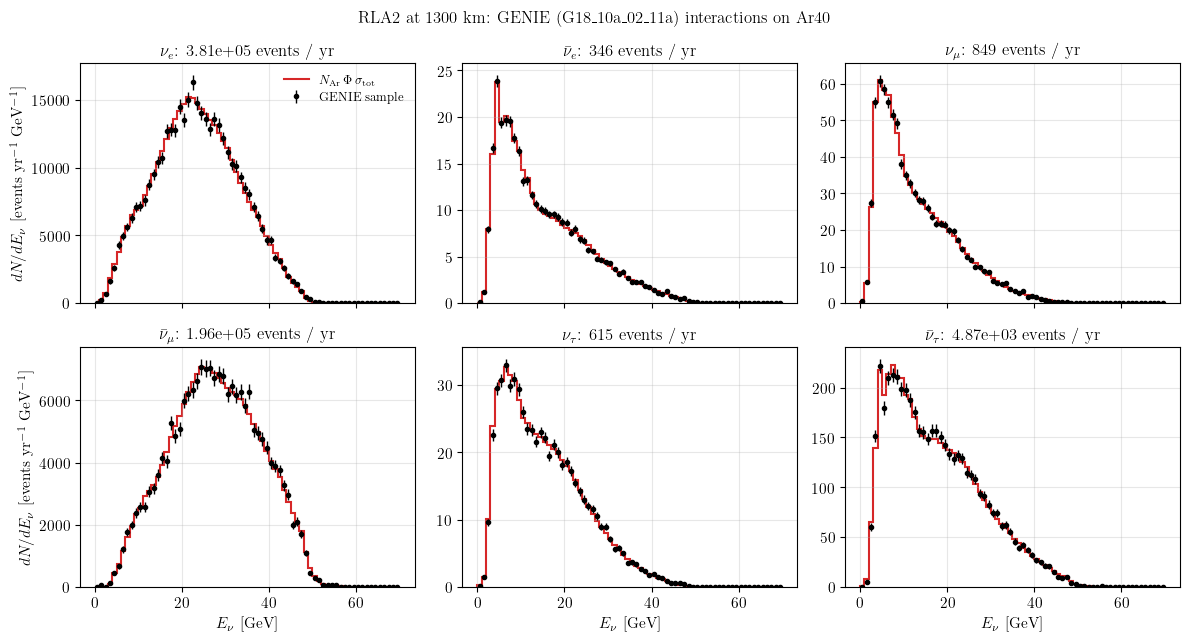

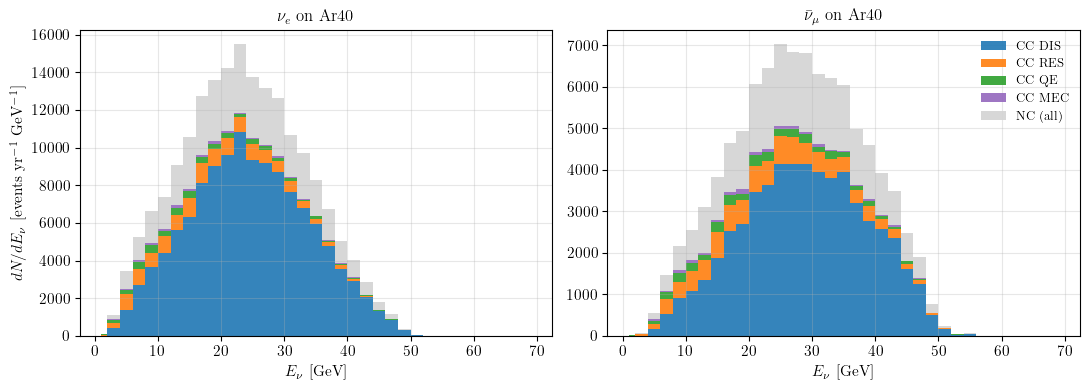

In [4]:
nu_tex = {
    "nue": r"$\nu_e$", "nuebar": r"$\bar\nu_e$", "numu": r"$\nu_\mu$",
    "numubar": r"$\bar\nu_\mu$", "nutau": r"$\nu_\tau$", "nutaubar": r"$\bar\nu_\tau$",
}
genie_events = {}

for name in GENIE_MACHINES:
    slug = name.lower()
    norm = genie_norm[name]["flavors"]
    genie_events[name] = {
        flavor: gt.read_gst(r["gst"]) for flavor, r in genie_runs[name].items() if r["gst"]
    }

    # Closure test: sample vs the flux x sigma expectation, flavor by flavor.
    fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharex=True)
    for ax, flavor in zip(axes.flat, gt.NU_FLAVORS):
        if flavor not in genie_events[name]:
            ax.set_visible(False)
            continue
        e = norm[flavor]
        edges = e["energy_edges"]
        step = max(1, (edges.size - 1) // 70)          # ~70 plotting bins
        plot_edges = edges[::step]
        centers = 0.5 * (plot_edges[1:] + plot_edges[:-1])
        widths = np.diff(plot_edges)

        counts, _ = np.histogram(genie_events[name][flavor]["Ev"], bins=plot_edges)
        w = e["weight_per_event"]
        ax.errorbar(centers, counts * w / widths, yerr=np.sqrt(counts) * w / widths,
                    fmt="o", ms=3, lw=1, color="black", label="GENIE sample")
        expected = gt.resample_flux(edges, e["spectrum"], plot_edges, method="conserve")
        ax.stairs(expected, plot_edges, color="tab:red", lw=1.5,
                  label=r"$N_{\rm Ar}\,\Phi\,\sigma_{\rm tot}$")
        ax.set_title(f"{nu_tex[flavor]}: {e['events_per_year_genie']:.3g} events / yr")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, None)
    for ax in axes[-1]:
        ax.set_xlabel(r"$E_\nu$ [GeV]")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(f"{name} at 1300 km: GENIE ({genie.tune}) interactions on Ar40")
    fig.tight_layout()
    fig.savefig(f"plots/{slug}_genie_interaction_spectra.pdf", dpi=300, bbox_inches="tight")

    # Interaction types. All fractions, weighted, per flavor.
    procs = ("qel", "mec", "res", "dis", "coh")
    print(f"{name} interaction fractions (CC+NC):")
    print(f"{'flavor':>9} {'CC':>6} {'NC':>6} | " + " ".join(f"{p:>6}" for p in procs))
    for flavor, ev in genie_events[name].items():
        n = len(ev["Ev"])
        print(f"{flavor:>9} {ev['cc'].sum() / n:6.3f} {ev['nc'].sum() / n:6.3f} | "
              + " ".join(f"{ev[p].sum() / n:6.3f}" for p in procs))

    # Stacked by channel for the two flavors that carry the rate.
    channels = (("dis", "CC DIS", "tab:blue"), ("res", "CC RES", "tab:orange"),
                ("qel", "CC QE", "tab:green"), ("mec", "CC MEC", "tab:purple"))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
    for ax, flavor in zip(axes, ("nue", "numubar")):
        if flavor not in genie_events[name]:
            continue
        ev = genie_events[name][flavor]
        e = norm[flavor]
        edges = e["energy_edges"]
        plot_edges = edges[::max(1, (edges.size - 1) // 35)]
        w = e["weight_per_event"] / np.diff(plot_edges)
        stack, labels, colors = [], [], []
        for key, label, color in channels:
            sel = (ev[key] == 1) & (ev["cc"] == 1)
            stack.append(np.histogram(ev["Ev"][sel], bins=plot_edges)[0] * w)
            labels.append(label); colors.append(color)
        stack.append(np.histogram(ev["Ev"][ev["nc"] == 1], bins=plot_edges)[0] * w)
        labels.append("NC (all)"); colors.append("lightgray")
        ax.stackplot(0.5 * (plot_edges[1:] + plot_edges[:-1]), stack,
                     labels=labels, colors=colors, step="mid", alpha=0.9)
        ax.set_title(f"{nu_tex[flavor]} on Ar40")
        ax.set_xlabel(r"$E_\nu$ [GeV]")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
    axes[1].legend(frameon=False, fontsize=9, loc="upper right")
    fig.tight_layout()
    fig.savefig(f"plots/{slug}_genie_interaction_channels.pdf", dpi=300, bbox_inches="tight")

### Notes

- **The $\nu_\tau$ rates come down.** The e and $\mu$ flavors agree with section 8 to a
  few percent, but GENIE finds roughly half the $\nu_\tau$ / $\bar\nu_\tau$ rate. The
  `tau_threshold_factor` in `mint.xsecs` is a crude kinematic suppression; GENIE carries
  $m_\tau$ through the QE, RES and DIS kinematics properly. Take GENIE's number.
- **Logs are bounded on purpose.** This development build of GENIE prints a full Pythia8
  event listing for every DIS event (a hard-coded `gPythia->event.list()` in
  `Pythia8Hadro2019.cxx`), about a kilobyte per event, so only the last few hundred
  lines of each job are kept in `gevgen.log`. The `ERROR Kinematics: Negative cross
  section` messages in there are GENIE's normal rejection-sampling chatter.
- **Vertices are all at the origin**, pointing along $+z$: a histogram flux carries no
  geometry. That is enough for the energy and flavor content, interaction types and
  final states; a full detector simulation would need a ray-level flux (`dk2nu` /
  `gsimple`) and a GENIE build with `--enable-fnal`.
- The `.gst.root` files are ordinary flat ROOT trees: `Ev`, the lepton four-momentum
  `El, pxl, pyl, pzl`, final-state multiplicities `nfp, nfn, nfpip, nfpim, nfpi0`, and
  the process flags `cc, nc, qel, mec, res, dis, coh`. `gt.read_gst(path, branches=...)`
  pulls any of them; the `.ghep.root` next to each has the complete event record.

## 11. GENIE for the low-energy machines: RLA1 and PA

The same chain for the two accelerator stages upstream of RLA2, with the same far
detector at $L = 1300$ km. Their fluxes were sampled at each machine's own $1/r^2$
onset and scaled out to the baseline in section 9 (`data/genie/rla1_dune_flux.root`,
`data/genie/pa_dune_flux.root`: 289 m with a 3 m face for RLA1, 588 m with a 25 m
face for PA), so all that happens here is the GENIE step and the plots.

Two things are different at these energies:

- **Rates are tiny.** RLA1 gives a few hundred events per year, PA a few tens. The
  20k-event samples are still worth generating: GENIE is drawing the *shape*, and the
  weights per event just come out small.
- **This is where GENIE changes the answer most.** Below a few GeV the interactions are
  quasi-elastic and resonant, exactly the regime section 4 warned about: the notebook's
  $\sigma \propto E$ extrapolation of the DIS tables is a poor description there, so the
  GENIE / section-8 ratios below are expected to move well away from 1. The $\nu_\tau$
  CC channel is below threshold for PA altogether (NC only) and mostly so for RLA1.

Needs cell 46 (`genie`, `gt`, `N_GENIE_EVENTS`) to have run.

In [32]:
# GENIE on the RLA1 and PA fluxes; extends the section-10 dictionaries.
LOW_ENERGY_MACHINES = ["RLA1", "PA"]

for name in LOW_ENERGY_MACHINES:
    slug = name.lower()
    t0 = time.time()
    genie_runs[name] = gt.run_gevgen_all(
        genie,
        flux_root=f"data/genie/{slug}_dune_flux.root",
        n_events=N_GENIE_EVENTS,
        workdir=f"data/genie/runs/{slug}",
    )
    print(f"{name}: {time.time() - t0:.0f} s wall for {len(genie_runs[name])} parallel jobs")
    for flavor, r in genie_runs[name].items():
        status = "ok" if r["gst"] else f"FAILED (gevgen exit {r['returncode']}; see {r['log']})"
        print(f"   {flavor:9s} {r['n_events']:>7d} events  {r['seconds']:5.0f} s  {status}")

    genie_norm[name] = gt.genie_normalization(
        genie, f"data/genie/{slug}_dune_flux.root", n_generated=N_GENIE_EVENTS
    )
    print(f"\n===== {name}: GENIE ({genie.tune}) against this notebook's section 8 =====")
    gt.print_normalization(genie_norm[name])
    print()

RLA1: 237 s wall for 6 parallel jobs
   nue         20000 events    202 s  ok
   nuebar      20000 events    236 s  ok
   numu        20000 events    188 s  ok
   numubar     20000 events    187 s  ok
   nutau       20000 events     41 s  ok
   nutaubar    20000 events     42 s  ok

===== RLA1: GENIE (G18_10a_02_11a) against this notebook's section 8 =====
   flavor  flux [/cm2/yr] <sigma> [cm2]  GENIE ev/yr  MINT ev/yr  ratio   wt/event
      nue      1.1731e+04     8.261e-37   4.6243e+02  3.5757e+02  1.293  2.312e-02
   nuebar      3.3059e+02     3.887e-37   6.1320e+00  6.1568e+00  0.996  3.066e-04
     numu      3.1275e+02     8.578e-37   1.2802e+01  1.0258e+01  1.248  6.401e-04
  numubar      3.9386e+03     2.362e-37   4.4394e+01  4.9626e+01  0.895  2.220e-03
    nutau      5.0357e+02     2.055e-37   4.9390e+00  6.5650e+00  0.752  2.470e-04
 nutaubar      8.2633e+03     1.251e-37   4.9328e+01  7.9402e+01  0.621  2.466e-03

PA: 988 s wall for 6 parallel jobs
   nue         20000 eve

RLA1 interaction fractions (CC+NC):
   flavor     CC     NC |    qel    mec    res    dis    coh
      nue  0.751  0.248 |  0.289  0.070  0.416  0.221  0.005
   nuebar  0.693  0.306 |  0.287  0.086  0.423  0.192  0.012
     numu  0.742  0.258 |  0.271  0.062  0.424  0.239  0.004
  numubar  0.671  0.329 |  0.373  0.111  0.381  0.127  0.009
    nutau  0.002  0.998 |  0.269  0.038  0.454  0.234  0.005
 nutaubar  0.001  0.999 |  0.298  0.039  0.439  0.211  0.012

PA interaction fractions (CC+NC):
   flavor     CC     NC |    qel    mec    res    dis    coh
      nue  0.714  0.286 |  0.655  0.122  0.202  0.020  0.002
   nuebar  0.560  0.440 |  0.646  0.145  0.178  0.022  0.007
     numu  0.650  0.350 |  0.716  0.112  0.155  0.015  0.001
  numubar  0.540  0.460 |  0.661  0.143  0.168  0.022  0.006
    nutau  0.000  1.000 |  0.742  0.082  0.153  0.022  0.002
 nutaubar  0.000  1.000 |  0.666  0.084  0.205  0.035  0.009



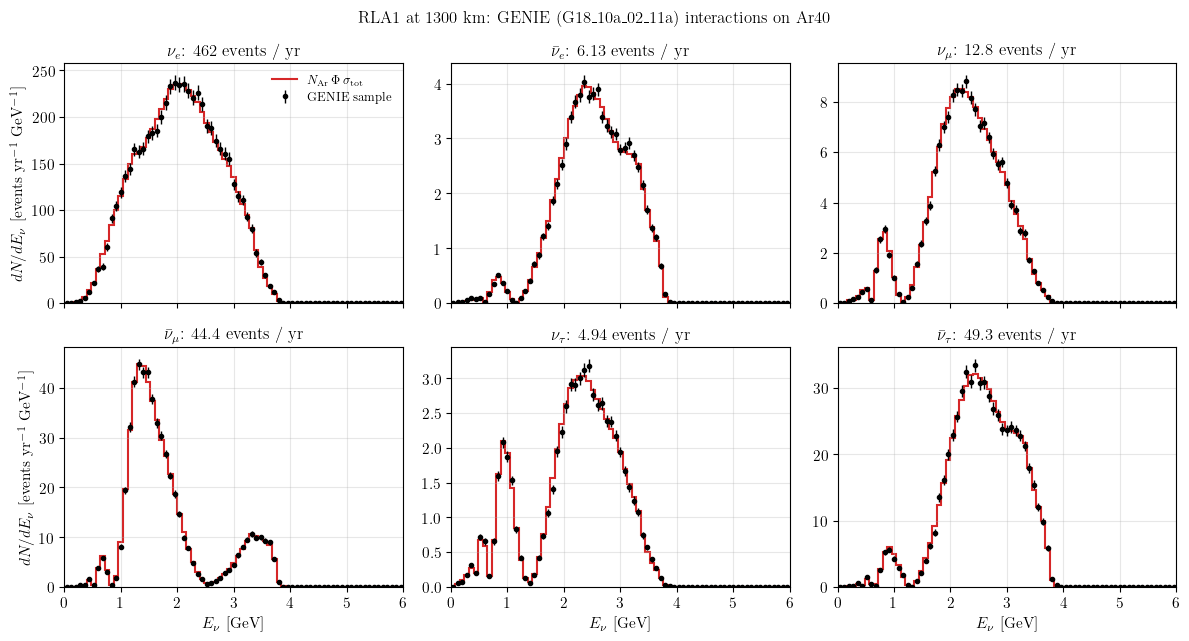

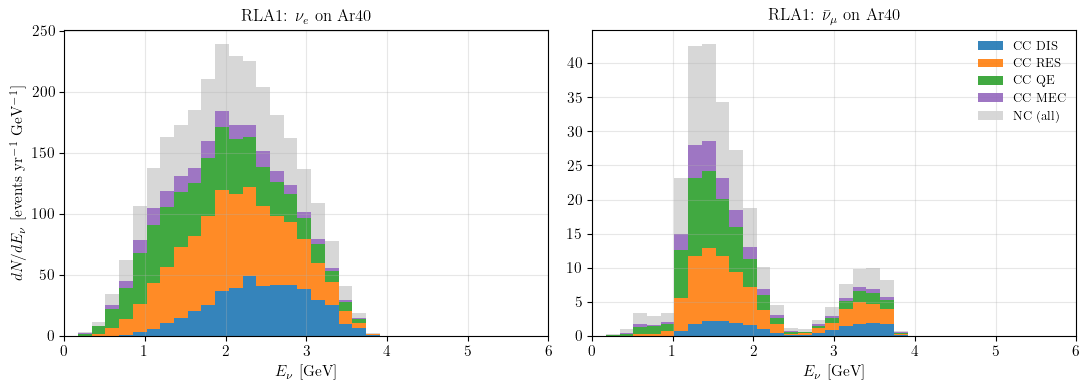

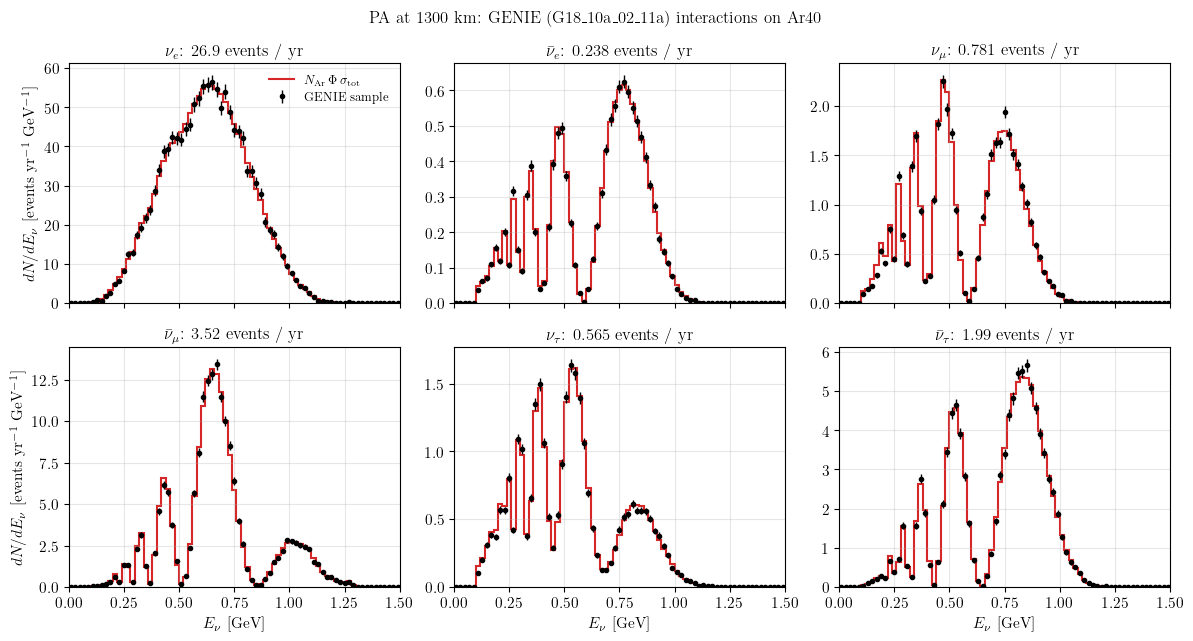

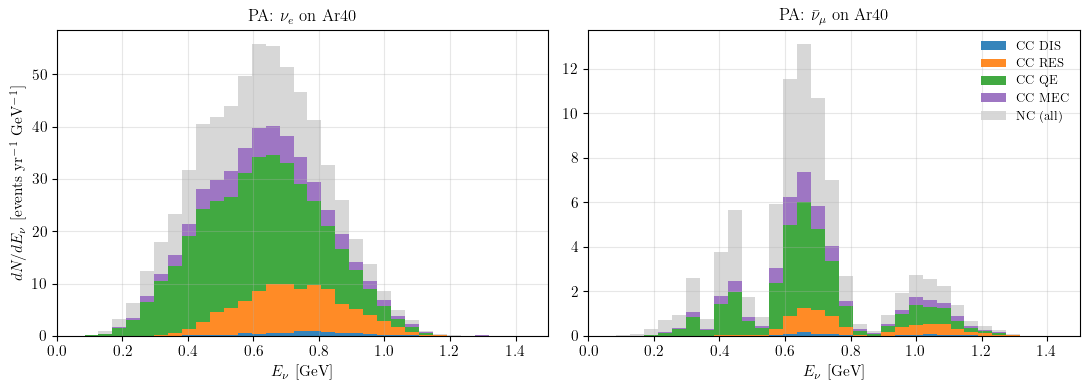

In [33]:
# Section 10's figures, as functions, for any machine that has been run.

def genie_closure_figure(name, n_plot_bins=70):
    """GENIE sample (points, weighted to events/yr/GeV) against N_Ar Phi sigma_tot."""
    slug = name.lower()
    norm = genie_norm[name]["flavors"]
    events = genie_events.setdefault(name, {})
    for flavor, r in genie_runs[name].items():
        if r["gst"] and flavor not in events:
            events[flavor] = gt.read_gst(r["gst"])

    fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharex=True)
    for ax, flavor in zip(axes.flat, gt.NU_FLAVORS):
        if flavor not in events:
            ax.set_visible(False)
            continue
        e = norm[flavor]
        edges = e["energy_edges"]
        plot_edges = edges[::max(1, (edges.size - 1) // n_plot_bins)]
        centers = 0.5 * (plot_edges[1:] + plot_edges[:-1])
        widths = np.diff(plot_edges)
        counts, _ = np.histogram(events[flavor]["Ev"], bins=plot_edges)
        w = e["weight_per_event"]
        ax.errorbar(centers, counts * w / widths, yerr=np.sqrt(counts) * w / widths,
                    fmt="o", ms=3, lw=1, color="black", label="GENIE sample")
        expected = gt.resample_flux(edges, e["spectrum"], plot_edges, method="conserve")
        ax.stairs(expected, plot_edges, color="tab:red", lw=1.5,
                  label=r"$N_{\rm Ar}\,\Phi\,\sigma_{\rm tot}$")
        ax.set_title(f"{nu_tex[flavor]}: {e['events_per_year_genie']:.3g} events / yr")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, None)
        ax.set_xlim(edges[0], edges[-1])
    for ax in axes[-1]:
        ax.set_xlabel(r"$E_\nu$ [GeV]")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(f"{name} at 1300 km: GENIE ({genie.tune}) interactions on Ar40")
    fig.tight_layout()
    fig.savefig(f"plots/{slug}_genie_interaction_spectra.pdf", dpi=300, bbox_inches="tight")
    return fig


def genie_fraction_table(name):
    """Interaction-type fractions of the generated sample, per flavor."""
    procs = ("qel", "mec", "res", "dis", "coh")
    print(f"{name} interaction fractions (CC+NC):")
    print(f"{'flavor':>9} {'CC':>6} {'NC':>6} | " + " ".join(f"{p:>6}" for p in procs))
    for flavor, ev in genie_events[name].items():
        n = len(ev["Ev"])
        print(f"{flavor:>9} {ev['cc'].sum() / n:6.3f} {ev['nc'].sum() / n:6.3f} | "
              + " ".join(f"{ev[p].sum() / n:6.3f}" for p in procs))


def genie_channels_figure(name, flavors=("nue", "numubar"), n_plot_bins=35):
    """The rate-carrying flavors split by interaction channel."""
    slug = name.lower()
    channels = (("dis", "CC DIS", "tab:blue"), ("res", "CC RES", "tab:orange"),
                ("qel", "CC QE", "tab:green"), ("mec", "CC MEC", "tab:purple"))
    fig, axes = plt.subplots(1, len(flavors), figsize=(5.5 * len(flavors), 4))
    for ax, flavor in zip(np.atleast_1d(axes), flavors):
        if flavor not in genie_events[name]:
            continue
        ev = genie_events[name][flavor]
        e = genie_norm[name]["flavors"][flavor]
        edges = e["energy_edges"]
        plot_edges = edges[::max(1, (edges.size - 1) // n_plot_bins)]
        w = e["weight_per_event"] / np.diff(plot_edges)
        stack, labels, colors = [], [], []
        for key, label, color in channels:
            sel = (ev[key] == 1) & (ev["cc"] == 1)
            stack.append(np.histogram(ev["Ev"][sel], bins=plot_edges)[0] * w)
            labels.append(label); colors.append(color)
        stack.append(np.histogram(ev["Ev"][ev["nc"] == 1], bins=plot_edges)[0] * w)
        labels.append("NC (all)"); colors.append("lightgray")
        ax.stackplot(0.5 * (plot_edges[1:] + plot_edges[:-1]), stack,
                     labels=labels, colors=colors, step="mid", alpha=0.9)
        ax.set_title(f"{name}: {nu_tex[flavor]} on Ar40")
        ax.set_xlabel(r"$E_\nu$ [GeV]")
        ax.set_xlim(edges[0], edges[-1])
        ax.grid(True, alpha=0.3)
    np.atleast_1d(axes)[0].set_ylabel(r"$dN/dE_\nu$ [events yr$^{-1}$ GeV$^{-1}$]")
    np.atleast_1d(axes)[-1].legend(frameon=False, fontsize=9, loc="upper right")
    fig.tight_layout()
    fig.savefig(f"plots/{slug}_genie_interaction_channels.pdf", dpi=300, bbox_inches="tight")
    return fig


for name in LOW_ENERGY_MACHINES:
    genie_closure_figure(name)
    genie_fraction_table(name)
    genie_channels_figure(name)
    print()